In [2]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import gzip
import urllib.request as request
import os
import torch.optim as optim
import torchvision.datasets as datasets
import h5py
import time
import pandas as pd
import math
from torch.optim import Adam
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader, random_split
from torch.utils.data import Subset
from torchmetrics.image import StructuralSimilarityIndexMeasure

In [3]:
class JetsDataset(Dataset):

    def __init__(self, file_path, percentile=99.5):
        with h5py.File(file_path, 'r') as f:
            X = f['X_diffusion'][:].astype(np.float32)
            self.y = f['y'][:].astype(np.int64)
        print('ESTADÍSTICAS ORIGINALES DEL ARCHIVO')
        print('\n')
        print('Shape:', X.shape)
        print('Min global :', X.min())
        print('Max global :', X.max())
        print('Mean global:', X.mean())
        print('Std global :', X.std())
        if X.min() < 0:
            X01 = (X + 1.0) / 2.0
        else:
            X01 = X.copy()
        X01 = np.clip(X01, 0.0, None)
        print('\n')
        print('[0, 1]')
        print('Min:', X01.min())
        print('Max:', X01.max())
        print('Mean:', X01.mean())
        print('Std:', X01.std())
        activos = X01[X01 > 0]
        if activos.size == 0:
            self.scale = 1.0
        else:
            self.scale = np.percentile(activos, percentile)
        print('\n')
        print('ESCALA DE INTENSIDAD')
        print(f'Percentil activo {percentile}:', self.scale)
        X01 = X01 / (self.scale + 1e-08)
        X01 = np.clip(X01, 0.0, 1.0)
        X_scaled = 2.0 * X01 - 1.0
        self.X = X_scaled.astype(np.float32)
        print('\n' )
        print('ESTADÍSTICAS')
        print('Min global :', self.X.min())
        print('Max global :', self.X.max())
        print('Mean global:', self.X.mean())
        print('Std global :', self.X.std())

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        x = torch.from_numpy(self.X[idx]).float().permute(2, 0, 1)
        y = torch.tensor(self.y[idx], dtype=torch.long)
        return (x, y)

def inspeccionar_imagen(img, label=None):
    print('\n')
    print('IMAGEN')
    if label is not None:
        print('label =', label)
    print('shape =', img.shape)
    print('min   =', img.min().item())
    print('max   =', img.max().item())
    print('mean  =', img.mean().item())
    print('std   =', img.std().item())
    print('\n')
    print('RANGO POR CANAL')
    nombres = ['ECAL', 'HCAL', 'TRACKER']
    for c, nombre in enumerate(nombres):
        canal = img[c]
        activos = canal[canal > -0.99]
        print(f'\n{nombre}')
        print('min total :', canal.min().item())
        print('max total :', canal.max().item())
        print('mean total:', canal.mean().item())
        print('std total :', canal.std().item())
        print('pix activos:', activos.numel(), '/', canal.numel())
        if activos.numel() > 0:
            print('min activo :', activos.min().item())
            print('max activo :', activos.max().item())
            print('mean activo:', activos.mean().item())
            print('std activo :', activos.std().item())

def visualizar_canales(img):
    img = img.detach().cpu()
    nombres = ['ECAL', 'HCAL', 'TRACKER']
    fig, ax = plt.subplots(1, 3, figsize=(15, 5))
    for c, nombre in enumerate(nombres):
        im = ax[c].imshow(img[c].numpy(), origin='lower')
        ax[c].set_title(nombre)
        ax[c].axis('off')
        plt.colorbar(im, ax=ax[c], fraction=0.046)
    plt.tight_layout()
    plt.show()

def visualizar_rgb_jet(img, channel_order=(2, 0, 1), title='Jet RGB: R=Tracker, G=ECAL, B=HCAL', contrast=True):
    img = img.detach().cpu()
    img01 = (img + 1.0) / 2.0
    img01 = img01.clamp(0, 1)
    img01 = img01[list(channel_order)]
    if contrast:
        img_vis = img01.clone()
        for c in range(img_vis.shape[0]):
            canal = img_vis[c]
            activos = canal[canal > 1e-06]
            if activos.numel() > 0:
                vmax = torch.quantile(activos, 0.99)
                img_vis[c] = canal / (vmax + 1e-08)
        img_vis = img_vis.clamp(0, 1)
    else:
        img_vis = img01
    img_rgb = img_vis.permute(1, 2, 0).numpy()
    plt.figure(figsize=(6, 6))
    plt.imshow(img_rgb, origin='lower')
    plt.title(title)
    plt.axis('off')
    plt.show()

def visualizar_rgb_simple(img):
    img = img.detach().cpu()
    img_rgb = img.permute(1, 2, 0).numpy()
    img_rgb = (img_rgb + 1.0) / 2.0
    img_rgb = np.clip(img_rgb, 0, 1)
    plt.figure(figsize=(6, 6))
    plt.imshow(img_rgb, origin='lower')
    plt.title('Jet RGB simple')
    plt.axis('off')
    plt.show()

ESTADÍSTICAS ORIGINALES DEL ARCHIVO


Shape: (139306, 64, 64, 3)
Min global : -1.0
Max global : 1.0
Mean global: -0.99999624
Std global : 0.002143081


[0, 1]
Min: 0.0
Max: 1.0
Mean: 6.293778e-05
Std: 0.0010698059


ESCALA DE INTENSIDAD
Percentil activo 99.5: 0.028265983


ESTADÍSTICAS
Min global : -1.0
Max global : 1.0
Mean global: -0.99695355
Std global : 0.051292248


IMAGEN
label = tensor(0)
shape = torch.Size([3, 64, 64])
min   = -1.0
max   = 1.0
mean  = -0.9958806037902832
std   = 0.03815007582306862


RANGO POR CANAL

ECAL
min total : -1.0
max total : 0.2988485097885132
mean total: -0.9970977306365967
std total : 0.031059639528393745
pix activos: 145 / 4096
min activo : -0.9896167516708374
max activo : 0.2988485097885132
mean activo: -0.9194411635398865
std activo : 0.14535829424858093

HCAL
min total : -1.0
max total : 1.0
mean total: -0.9945652484893799
std total : 0.04931170120835304
pix activos: 230 / 4096
min activo : -0.9899119734764099
max activo : 1.0
mean activo: -0.904

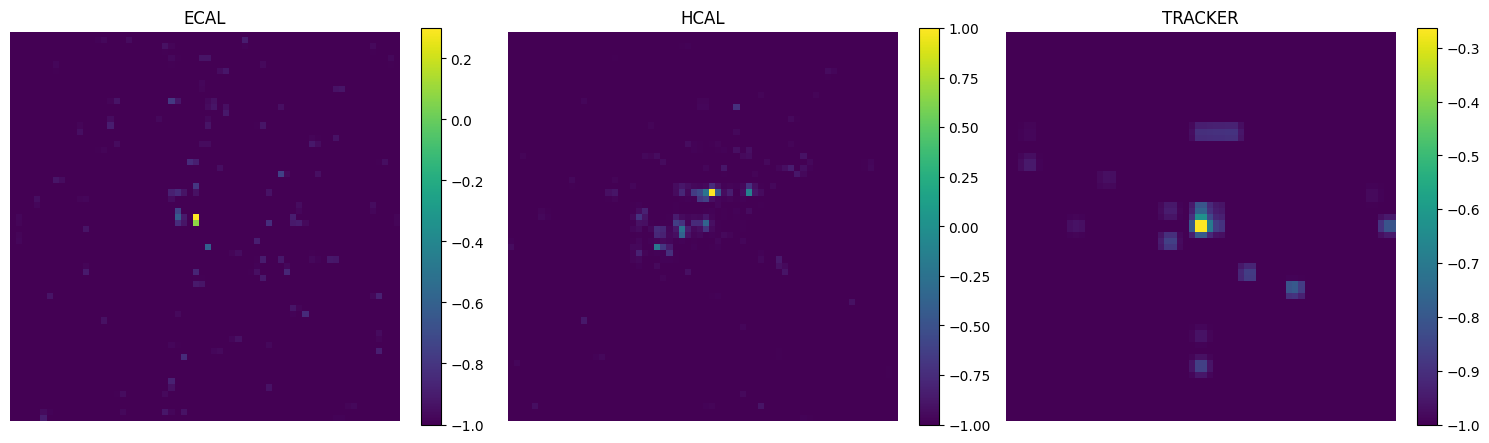

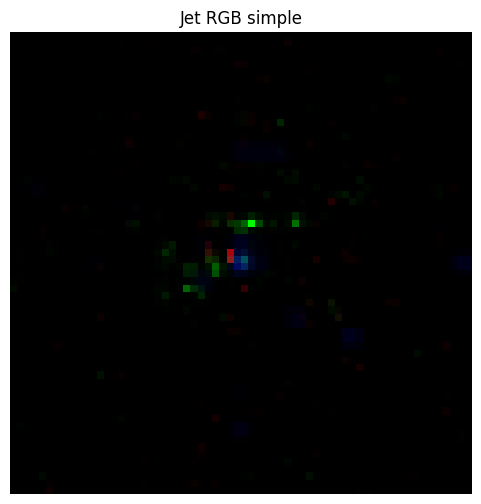

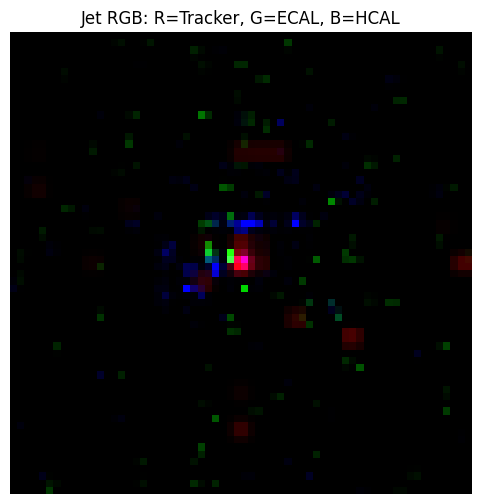

DATASET
Total dataset: 139306
Train dataset: 10000
Test dataset : 2500
BATCH
x_batch: torch.Size([16, 3, 64, 64])
y_batch: torch.Size([16])
batch min : -1.0
batch max : 1.0
batch mean: -0.9955604672431946
batch std : 0.05333169922232628


In [4]:
file_path = 'Diffusion_jets_procesados_por_canal.hdf5'
full_dataset = JetsDataset(file_path)
img, label = full_dataset[0]

inspeccionar_imagen(img, label)
visualizar_canales(img)
visualizar_rgb_simple(img)
visualizar_rgb_jet(img)

train_size = int(0.8 * len(full_dataset))
test_size = len(full_dataset) - train_size
train_dataset_full, test_dataset_full = random_split(full_dataset, [train_size, test_size], generator=torch.Generator().manual_seed(42))
usar_subset_pequeno = True
train_small_size = 10000
test_small_size = 2500

if usar_subset_pequeno:
    train_dataset = Subset(train_dataset_full, range(min(train_small_size, len(train_dataset_full))))
    test_dataset = Subset(test_dataset_full, range(min(test_small_size, len(test_dataset_full))))
else:
    train_dataset = train_dataset_full
    test_dataset = test_dataset_full
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False, num_workers=0)
x_batch, y_batch = next(iter(train_loader))

print('DATASET')
print('Total dataset:', len(full_dataset))
print('Train dataset:', len(train_dataset))
print('Test dataset :', len(test_dataset))
print('BATCH')
print('x_batch:', x_batch.shape)
print('y_batch:', y_batch.shape)
print('batch min :', x_batch.min().item())
print('batch max :', x_batch.max().item())
print('batch mean:', x_batch.mean().item())
print('batch std :', x_batch.std().item())

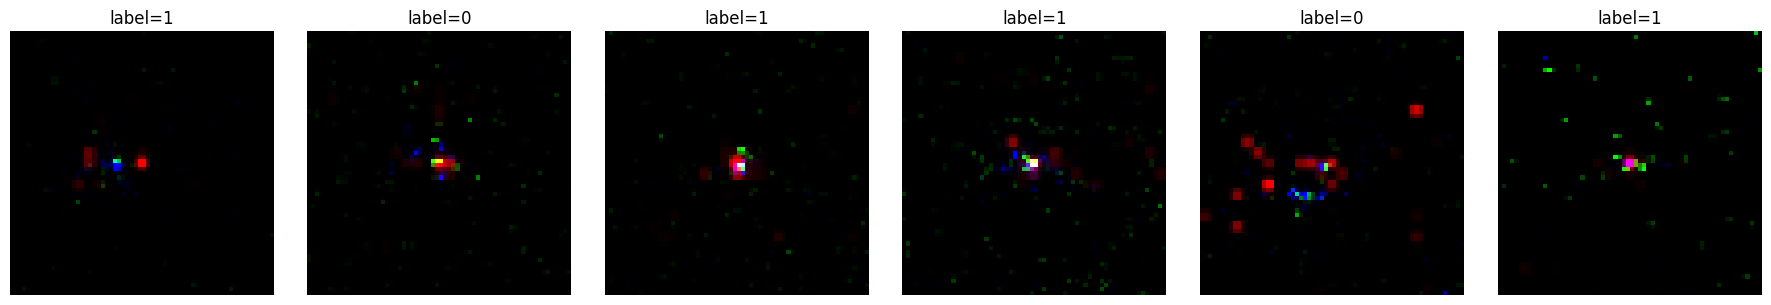

In [4]:
n = 6
fig, ax = plt.subplots(1, n, figsize=(3 * n, 3))
for i in range(n):
    img_i = x_batch[i].detach().cpu()
    img01 = (img_i + 1.0) / 2.0
    img01 = img01.clamp(0, 1)
    img01 = img01[[2, 0, 1]]
    img_vis = img01.clone()
    for c in range(3):
        canal = img_vis[c]
        activos = canal[canal > 1e-06]
        if activos.numel() > 0:
            vmax = torch.quantile(activos, 0.99)
            img_vis[c] = canal / (vmax + 1e-08)
    img_vis = img_vis.clamp(0, 1)
    img_rgb = img_vis.permute(1, 2, 0).numpy()
    ax[i].imshow(img_rgb, origin='lower')
    ax[i].set_title(f'label={y_batch[i].item()}')
    ax[i].axis('off')
plt.tight_layout()
plt.show()

--------------------------------------------------
Total de imágenes revisadas: 10000

MÁXIMOS POR IMAGEN
Máximo absoluto : 1.000000
Máximo promedio : 0.934415
Percentil 99    : 1.000000
Percentil 99.9  : 1.000000

PÍXELES ACTIVOS POR IMAGEN
Promedio        : 567.97
Mediana         : 550.00
Percentil 99    : 1028.00

SUMA TOTAL POR IMAGEN
Suma promedio   : 25.033385
Suma mediana    : 24.063066
Percentil 99    : 45.699089


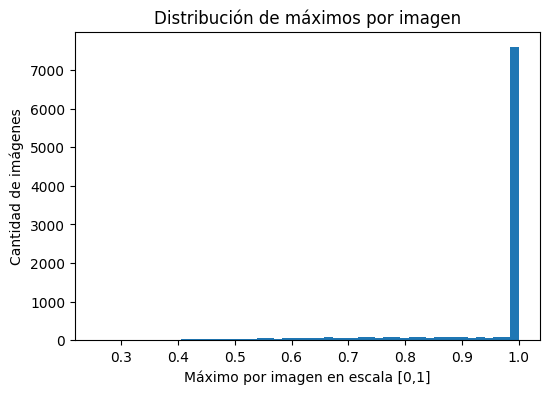

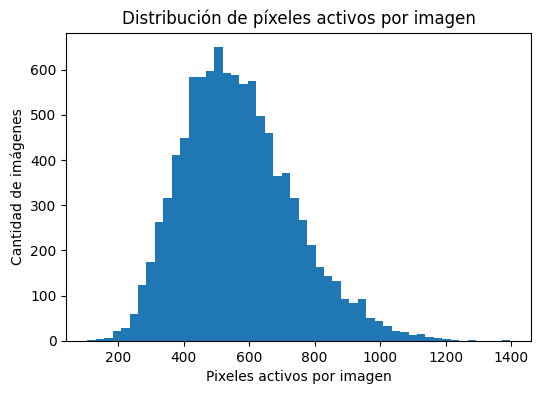

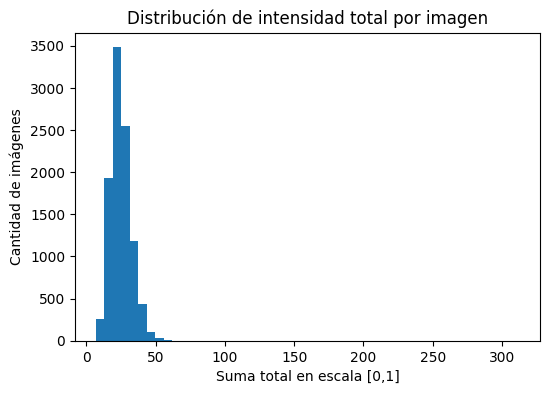

In [ ]:
buscador_loader = DataLoader(train_dataset, batch_size=64, shuffle=False)
todos_los_maximos = []
todos_los_pixeles_activos = []
todos_los_sumas = []
with torch.no_grad():
    for imagenes, labels in buscador_loader:
        imagenes_01 = (imagenes + 1.0) / 2.0
        imagenes_01 = imagenes_01.clamp(0, 1)
        maximos_lote = imagenes_01.amax(dim=(1, 2, 3))
        pixeles_activos_lote = (imagenes_01 > 0.0001).sum(dim=(1, 2, 3))
        sumas_lote = imagenes_01.sum(dim=(1, 2, 3))
        todos_los_maximos.extend(maximos_lote.cpu().tolist())
        todos_los_pixeles_activos.extend(pixeles_activos_lote.cpu().tolist())
        todos_los_sumas.extend(sumas_lote.cpu().tolist())
todos_los_maximos = np.array(todos_los_maximos)
todos_los_pixeles_activos = np.array(todos_los_pixeles_activos)
todos_los_sumas = np.array(todos_los_sumas)

print(f'Total de imágenes revisadas: {len(todos_los_maximos)}')
print('\nMÁXIMOS POR IMAGEN')
print(f'Máximo absoluto : {todos_los_maximos.max():.6f}')
print(f'Máximo promedio : {todos_los_maximos.mean():.6f}')
print(f'Percentil 99    : {np.percentile(todos_los_maximos, 99):.6f}')
print(f'Percentil 99.9  : {np.percentile(todos_los_maximos, 99.9):.6f}')
print('\nPÍXELES ACTIVOS POR IMAGEN')
print(f'Promedio        : {todos_los_pixeles_activos.mean():.2f}')
print(f'Mediana         : {np.median(todos_los_pixeles_activos):.2f}')
print(f'Percentil 99    : {np.percentile(todos_los_pixeles_activos, 99):.2f}')
print('\nSUMA TOTAL POR IMAGEN')
print(f'Suma promedio   : {todos_los_sumas.mean():.6f}')
print(f'Suma mediana    : {np.median(todos_los_sumas):.6f}')
print(f'Percentil 99    : {np.percentile(todos_los_sumas, 99):.6f}')

plt.figure(figsize=(6, 4))
plt.hist(todos_los_maximos, bins=50)
plt.title('Distribución de máximos por imagen')
plt.xlabel('Máximo por imagen en escala [0,1]')
plt.ylabel('Cantidad de imágenes')
plt.show()

plt.figure(figsize=(6, 4))
plt.hist(todos_los_pixeles_activos, bins=50)
plt.title('Distribución de píxeles activos por imagen')
plt.xlabel('Pixeles activos por imagen')
plt.ylabel('Cantidad de imágenes')
plt.show()

plt.figure(figsize=(6, 4))
plt.hist(todos_los_sumas, bins=50)
plt.title('Distribución de intensidad total por imagen')
plt.xlabel('Suma total en escala [0,1]')
plt.ylabel('Cantidad de imágenes')
plt.show()

In [6]:
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')

## DDIM Scheduler and Reverse Process

The scheduler defines the forward noising process and the DDIM reverse update. The UNet predicts the velocity parameter $v$ from the noisy jet and its timestep; this prediction is converted into estimates of $x_0$ and the noise before each deterministic sampling step ($\eta=0$).


In [7]:
class DDIMScheduler:

    def __init__(self, num_timesteps, beta_s, beta_e, device, eta=0.0):
        self.num_timesteps = num_timesteps
        self.beta_s = beta_s
        self.beta_e = beta_e
        self.device = device
        self.eta = eta
        self.betas = torch.linspace(beta_s, beta_e, num_timesteps, device=device)
        self.alphas = 1.0 - self.betas
        self.alpha_cum_prod = torch.cumprod(self.alphas, dim=0)
        self.sqrt_alpha_cum_prod = torch.sqrt(self.alpha_cum_prod)
        self.sqrt_one_minus_alpha_cum_prod = torch.sqrt(1.0 - self.alpha_cum_prod)
        self.sqrt_recip_alphas = torch.sqrt(1.0 / self.alphas)
        self.alpha_cum_prod_prev = torch.cat([torch.tensor([1.0], device=device), self.alpha_cum_prod[:-1]], dim=0)
        self.posterior_variance = self.betas * (1.0 - self.alpha_cum_prod_prev) / (1.0 - self.alpha_cum_prod)
        self.posterior_mean_coef1 = self.betas * torch.sqrt(self.alpha_cum_prod_prev) / (1.0 - self.alpha_cum_prod)
        self.posterior_mean_coef2 = torch.sqrt(self.alphas) * (1.0 - self.alpha_cum_prod_prev) / (1.0 - self.alpha_cum_prod)
        self.inference_timesteps = None

    def sample_timesteps(self, batch_size):
        return torch.randint(0, self.num_timesteps, (batch_size,), device=self.device)

    def _extract(self, arr, t, x_shape):
        out = arr.gather(0, t)
        return out.view(t.shape[0], *[1] * (len(x_shape) - 1))

    def add_noise(self, x0, t, noise=None):
        if noise is None:
            noise = torch.randn_like(x0)
        sqrt_alpha_cum_prod_t = self._extract(self.sqrt_alpha_cum_prod, t, x0.shape)
        sqrt_one_minus_alpha_cum_prod_t = self._extract(self.sqrt_one_minus_alpha_cum_prod, t, x0.shape)
        xt = sqrt_alpha_cum_prod_t * x0 + sqrt_one_minus_alpha_cum_prod_t * noise
        return (xt, noise)

    def get_v_target(self, x0, noise, t):
        sqrt_alpha_bar_t = self._extract(self.sqrt_alpha_cum_prod, t, x0.shape)
        sqrt_one_minus_alpha_bar_t = self._extract(self.sqrt_one_minus_alpha_cum_prod, t, x0.shape)
        v_target = sqrt_alpha_bar_t * noise - sqrt_one_minus_alpha_bar_t * x0
        return v_target

    def set_timesteps(self, num_inference_steps):
        if num_inference_steps > self.num_timesteps:
            raise ValueError('num_inference_steps cannot be greater than num_timesteps.')
        timesteps = torch.linspace(self.num_timesteps - 1, 0, num_inference_steps, device=self.device).round().long()
        self.inference_timesteps = timesteps
        return timesteps

    @torch.no_grad()
    def _ddim_step(self, xt, x0_pred, noise_pred, t, t_prev):
        if isinstance(t, torch.Tensor):
            t_int = int(t.item())
        else:
            t_int = int(t)
        if isinstance(t_prev, torch.Tensor):
            t_prev_int = int(t_prev.item())
        else:
            t_prev_int = int(t_prev)
        alpha_bar_t = self.alpha_cum_prod[t_int].to(device=xt.device, dtype=xt.dtype)
        if t_prev_int >= 0:
            alpha_bar_prev = self.alpha_cum_prod[t_prev_int].to(device=xt.device, dtype=xt.dtype)
        else:
            alpha_bar_prev = torch.tensor(1.0, device=xt.device, dtype=xt.dtype)
        sigma = self.eta * torch.sqrt((1.0 - alpha_bar_prev) / (1.0 - alpha_bar_t)) * torch.sqrt(torch.clamp(1.0 - alpha_bar_t / alpha_bar_prev, min=0.0))
        direction_coefficient = torch.clamp(1.0 - alpha_bar_prev - sigma ** 2, min=0.0)
        pred_direction = torch.sqrt(direction_coefficient) * noise_pred
        if self.eta > 0.0 and t_prev_int >= 0:
            z = torch.randn_like(xt)
        else:
            z = torch.zeros_like(xt)
        x_prev = torch.sqrt(alpha_bar_prev) * x0_pred + pred_direction + sigma * z
        return (x_prev, x0_pred)

    @torch.no_grad()
    def sample_prev_timestep(self, xt, noise_pred, t, t_prev, clip_x0=True, recompute_noise_after_clipping=True):
        if isinstance(t, torch.Tensor):
            t_int = int(t.item())
        else:
            t_int = int(t)
        sqrt_alpha_bar_t = self.sqrt_alpha_cum_prod[t_int].to(device=xt.device, dtype=xt.dtype)
        sqrt_one_minus_alpha_bar_t = self.sqrt_one_minus_alpha_cum_prod[t_int].to(device=xt.device, dtype=xt.dtype)
        x0_pred = (xt - sqrt_one_minus_alpha_bar_t * noise_pred) / sqrt_alpha_bar_t
        if clip_x0:
            x0_pred = torch.clamp(x0_pred, -1.0, 1.0)
            if recompute_noise_after_clipping:
                noise_pred = (xt - sqrt_alpha_bar_t * x0_pred) / torch.clamp(sqrt_one_minus_alpha_bar_t, min=1e-08)
        return self._ddim_step(xt=xt, x0_pred=x0_pred, noise_pred=noise_pred, t=t, t_prev=t_prev)

    @torch.no_grad()
    def sample_prev_timestep_v(self, xt, v_pred, t, t_prev, clip_x0=True, recompute_noise_after_clipping=True):
        if isinstance(t, torch.Tensor):
            t_int = int(t.item())
        else:
            t_int = int(t)
        sqrt_alpha_bar_t = self.sqrt_alpha_cum_prod[t_int].to(device=xt.device, dtype=xt.dtype)
        sqrt_one_minus_alpha_bar_t = self.sqrt_one_minus_alpha_cum_prod[t_int].to(device=xt.device, dtype=xt.dtype)
        x0_pred = sqrt_alpha_bar_t * xt - sqrt_one_minus_alpha_bar_t * v_pred
        noise_pred = sqrt_one_minus_alpha_bar_t * xt + sqrt_alpha_bar_t * v_pred
        if clip_x0:
            x0_pred = torch.clamp(x0_pred, -1.0, 1.0)
            if recompute_noise_after_clipping:
                noise_pred = (xt - sqrt_alpha_bar_t * x0_pred) / torch.clamp(sqrt_one_minus_alpha_bar_t, min=1e-08)
        return self._ddim_step(xt=xt, x0_pred=x0_pred, noise_pred=noise_pred, t=t, t_prev=t_prev)

In [9]:
def get_num_groups(channels, max_groups=8):
    for g in reversed(range(1, max_groups + 1)):
        if channels % g == 0:
            return g
    return 1

def sinusoidal_time_embedding(timesteps, dim):
    if timesteps.dim() == 0:
        timesteps = timesteps[None]
    timesteps = timesteps.float()
    half_dim = dim // 2
    freqs = torch.exp(-math.log(10000) * torch.arange(half_dim, device=timesteps.device).float() / max(half_dim - 1, 1))
    args = timesteps[:, None] * freqs[None, :]
    emb = torch.cat([torch.sin(args), torch.cos(args)], dim=-1)
    if dim % 2 == 1:
        emb = F.pad(emb, (0, 1))
    return emb

class TimeEmbedding(nn.Module):
    def __init__(self, t_emb_dim):
        super().__init__()

        self.t_emb_dim = t_emb_dim

        self.mlp = nn.Sequential(
            nn.Linear(t_emb_dim, 4 * t_emb_dim),
            nn.SiLU(),
            nn.Linear(4 * t_emb_dim, t_emb_dim)
        )

    def forward(self, t):
        t_emb = sinusoidal_time_embedding(t, self.t_emb_dim)
        return self.mlp(t_emb)

In [10]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, t_emb_dim, dropout=0.0):
        super().__init__()

        self.norm1 = nn.GroupNorm(get_num_groups(in_channels), in_channels)
        self.conv1 = nn.Conv2d(
            in_channels,
            out_channels,
            kernel_size=3,
            padding=1
        )

        self.time_proj = nn.Sequential(
            nn.SiLU(),
            nn.Linear(t_emb_dim, 2 * out_channels)
        )

        self.norm2 = nn.GroupNorm(get_num_groups(out_channels), out_channels)
        self.dropout = nn.Dropout(dropout)

        self.conv2 = nn.Conv2d(
            out_channels,
            out_channels,
            kernel_size=3,
            padding=1
        )

        if in_channels != out_channels:
            self.skip = nn.Conv2d(in_channels, out_channels, kernel_size=1)
        else:
            self.skip = nn.Identity()

    def forward(self, x, t_emb):
        residual = self.skip(x)

        h = self.norm1(x)
        h = F.silu(h)
        h = self.conv1(h)

        scale_shift = self.time_proj(t_emb)
        scale, shift = scale_shift[:, :, None, None].chunk(2, dim=1)

        h = self.norm2(h)
        h = h * (1.0 + scale) + shift
        h = F.silu(h)
        h = self.dropout(h)
        h = self.conv2(h)

        return h + residual

In [11]:
class AttentionBlock(nn.Module):
    def __init__(self, channels, num_heads=4):
        super().__init__()

        assert channels % num_heads == 0

        self.num_heads = num_heads
        self.head_dim = channels // num_heads
        self.scale = self.head_dim ** -0.5

        self.norm = nn.GroupNorm(get_num_groups(channels), channels)
        self.qkv = nn.Conv2d(channels, 3 * channels, kernel_size=1)
        self.proj = nn.Conv2d(channels, channels, kernel_size=1)

    def forward(self, x):
        residual = x

        b, c, h, w = x.shape
        x = self.norm(x)

        q, k, v = self.qkv(x).chunk(3, dim=1)

        q = q.reshape(b, self.num_heads, self.head_dim, h * w)
        k = k.reshape(b, self.num_heads, self.head_dim, h * w)
        v = v.reshape(b, self.num_heads, self.head_dim, h * w)

        attn = torch.einsum("bhcn,bhcm->bhnm", q, k) * self.scale
        attn = attn.softmax(dim=-1)

        out = torch.einsum("bhnm,bhcm->bhcn", attn, v)
        out = out.reshape(b, c, h, w)

        return residual + self.proj(out)

In [12]:
class DownBlockStrong(nn.Module):
    def __init__(
        self,
        in_channels,
        out_channels,
        t_emb_dim,
        use_attention=False,
        dropout=0.0
    ):
        super().__init__()

        self.res1 = ResidualBlock(
            in_channels,
            out_channels,
            t_emb_dim,
            dropout=dropout
        )

        self.res2 = ResidualBlock(
            out_channels,
            out_channels,
            t_emb_dim,
            dropout=dropout
        )

        if use_attention:
            self.attn = AttentionBlock(out_channels)
        else:
            self.attn = nn.Identity()

        self.downsample = nn.Conv2d(
            out_channels,
            out_channels,
            kernel_size=4,
            stride=2,
            padding=1
        )

    def forward(self, x, t_emb, do_downsample=True):
        x = self.res1(x, t_emb)
        x = self.res2(x, t_emb)
        x = self.attn(x)

        skip = x

        if do_downsample:
            x = self.downsample(x)

        return x, skip

In [13]:
class MidBlock(nn.Module):
    def __init__(self, in_channels, out_channels, t_emb_dim, num_heads=4):
        super().__init__()

        self.resnet1 = ResidualBlock(in_channels, out_channels, t_emb_dim)
        self.attn = AttentionBlock(out_channels, num_heads)
        self.resnet2 = ResidualBlock(out_channels, out_channels, t_emb_dim)

    def forward(self, x, t_emb):

        x = self.resnet1(x, t_emb)
        x = self.attn(x)

        return self.resnet2(x, t_emb)

In [14]:
class UpBlockStrong(nn.Module):
    def __init__(
        self,
        in_channels,
        skip_channels,
        out_channels,
        t_emb_dim,
        use_attention=False,
        dropout=0.0
    ):
        super().__init__()

        self.res1 = ResidualBlock(
            in_channels + skip_channels,
            out_channels,
            t_emb_dim,
            dropout=dropout
        )

        self.res2 = ResidualBlock(
            out_channels,
            out_channels,
            t_emb_dim,
            dropout=dropout
        )

        if use_attention:
            self.attn = AttentionBlock(out_channels)
        else:
            self.attn = nn.Identity()

        self.upsample = nn.ConvTranspose2d(
            out_channels,
            out_channels,
            kernel_size=4,
            stride=2,
            padding=1
        )

    def forward(self, x, skip, t_emb, do_upsample=True):
        if x.shape[-2:] != skip.shape[-2:]:
            x = F.interpolate(x, size=skip.shape[-2:], mode="nearest")

        x = torch.cat([x, skip], dim=1)

        x = self.res1(x, t_emb)
        x = self.res2(x, t_emb)
        x = self.attn(x)

        if do_upsample:
            x = self.upsample(x)

        return x

In [15]:
class UNET(nn.Module):
    def __init__(
        self,
        im_channels=3,
        base_channels=64,
        channel_mults=(1, 2, 4, 4),
        t_emb_dim=256,
        img_size=64,
        attn_resolutions=(16, 8),
        dropout=0.0
    ):
        super().__init__()

        self.img_size = img_size
        self.attn_resolutions = attn_resolutions

        self.time_mlp = TimeEmbedding(t_emb_dim)

        self.conv_in = nn.Conv2d(
            im_channels,
            base_channels,
            kernel_size=3,
            padding=1
        )

        channels = [base_channels * m for m in channel_mults]

        self.downs = nn.ModuleList()

        in_channels = base_channels
        resolution = img_size

        for i, out_channels in enumerate(channels):
            use_attention = resolution in attn_resolutions

            self.downs.append(
                DownBlockStrong(
                    in_channels=in_channels,
                    out_channels=out_channels,
                    t_emb_dim=t_emb_dim,
                    use_attention=use_attention,
                    dropout=dropout
                )
            )

            in_channels = out_channels

            if i != len(channels) - 1:
                resolution //= 2

        mid_channels = channels[-1]

        self.mid1 = ResidualBlock(
            mid_channels,
            mid_channels,
            t_emb_dim,
            dropout=dropout
        )

        self.mid_attn = AttentionBlock(mid_channels)

        self.mid2 = ResidualBlock(
            mid_channels,
            mid_channels,
            t_emb_dim,
            dropout=dropout
        )

        self.ups = nn.ModuleList()

        reversed_channels = list(reversed(channels))
        resolutions = [img_size // (2 ** i) for i in range(len(channels))]
        reversed_resolutions = list(reversed(resolutions))

        in_channels = mid_channels

        for i, skip_channels in enumerate(reversed_channels):
            is_last = i == len(reversed_channels) - 1

            if i < len(reversed_channels) - 1:
                out_channels = reversed_channels[i + 1]
            else:
                out_channels = base_channels

            use_attention = reversed_resolutions[i] in attn_resolutions

            self.ups.append(
                UpBlockStrong(
                    in_channels=in_channels,
                    skip_channels=skip_channels,
                    out_channels=out_channels,
                    t_emb_dim=t_emb_dim,
                    use_attention=use_attention,
                    dropout=dropout
                )
            )

            in_channels = out_channels

        self.norm_out = nn.GroupNorm(
            get_num_groups(base_channels),
            base_channels
        )

        self.conv_out = nn.Conv2d(
            base_channels,
            im_channels,
            kernel_size=3,
            padding=1
        )

    def forward(self, x, t):
        t_emb = self.time_mlp(t)

        x = self.conv_in(x)

        skips = []

        for i, down in enumerate(self.downs):
            do_downsample = i != len(self.downs) - 1
            x, skip = down(x, t_emb, do_downsample=do_downsample)
            skips.append(skip)

        x = self.mid1(x, t_emb)
        x = self.mid_attn(x)
        x = self.mid2(x, t_emb)

        for i, up in enumerate(self.ups):
            skip = skips.pop()
            do_upsample = i != len(self.ups) - 1
            x = up(x, skip, t_emb, do_upsample=do_upsample)

        x = self.norm_out(x)
        x = F.silu(x)

        return self.conv_out(x)

In [ ]:
configuracion_inicial = {
    'diffusion_params': {'num_timesteps': 1000, 'beta_s': 0.0001, 'beta_e': 0.02},
    'model_params': {'im_channels': 3, 'im_size': 64},
    'train_params': {'task_name': 'default', 'batch_size': 16, 'num_epochs': 5, 'num_samples': 100, 'num_grid_rows': 10, 'lr': 0.0001},
}

## Sparse $v$-prediction Training

The training objective combines the global $v$-prediction error with additional penalties on active pixels, background suppression, and total deposited energy. These terms are especially important for calorimeter images, where most pixels are empty and a standard global loss can underestimate the sparse jet structure.


In [17]:
def sparse_ddim_v_loss_background_energy(
    v_pred, v_target, x_t, x0, t, scheduler, active_thr=-0.99, active_lambda=1.0, background_lambda=1.0,
    energy_lambda=1.0, bg_margin_01=0.0, eps=1e-08,
):
    error_v = (v_pred - v_target) ** 2
    loss_global = error_v.mean()
    active_mask = x0 > active_thr
    background_mask = x0 <= active_thr
    if active_mask.any():
        loss_active = error_v[active_mask].mean()
    else:
        loss_active = torch.tensor(0.0, device=x0.device)
    sqrt_alpha_bar_t = scheduler._extract(scheduler.sqrt_alpha_cum_prod, t, x0.shape)
    sqrt_one_minus_alpha_bar_t = scheduler._extract(scheduler.sqrt_one_minus_alpha_cum_prod, t, x0.shape)
    x0_pred = sqrt_alpha_bar_t * x_t - sqrt_one_minus_alpha_bar_t * v_pred
    x0_pred_01 = (x0_pred + 1.0) / 2.0
    x0_real_01 = (x0 + 1.0) / 2.0
    x0_pred_pos = torch.relu(x0_pred_01)
    if background_mask.any():
        background_excess = torch.relu(x0_pred_01[background_mask] - bg_margin_01)
        loss_background = background_excess.mean()
    else:
        loss_background = torch.tensor(0.0, device=x0.device)
    energy_pred = x0_pred_pos.sum(dim=(1, 2, 3))
    energy_real = x0_real_01.sum(dim=(1, 2, 3))
    loss_energy = F.mse_loss(torch.log1p(energy_pred), torch.log1p(energy_real))
    loss = loss_global + active_lambda * loss_active + background_lambda * loss_background + energy_lambda * loss_energy
    return (loss, loss_global, loss_active, loss_background, loss_energy)

In [ ]:
CANAL_NOMBRES = ['ECAL', 'HCAL', 'TRACKER']

@torch.no_grad()
def to_01(x):
    x = x.detach()
    if x.min().item() < -0.05:
        x = (x + 1.0) / 2.0
    return x.clamp(0.0, 1.0)

@torch.no_grad()
def wasserstein_xy_metric(x_pred, x_real, eps=1e-08):
    x_pred = to_01(x_pred)
    x_real = to_01(x_real)
    proj_x_pred = x_pred.sum(dim=1).sum(dim=1)
    proj_x_real = x_real.sum(dim=1).sum(dim=1)
    proj_y_pred = x_pred.sum(dim=1).sum(dim=2)
    proj_y_real = x_real.sum(dim=1).sum(dim=2)
    px_pred = proj_x_pred / (proj_x_pred.sum(dim=-1, keepdim=True) + eps)
    px_real = proj_x_real / (proj_x_real.sum(dim=-1, keepdim=True) + eps)
    py_pred = proj_y_pred / (proj_y_pred.sum(dim=-1, keepdim=True) + eps)
    py_real = proj_y_real / (proj_y_real.sum(dim=-1, keepdim=True) + eps)
    cdf_x_pred = torch.cumsum(px_pred, dim=-1)
    cdf_x_real = torch.cumsum(px_real, dim=-1)
    cdf_y_pred = torch.cumsum(py_pred, dim=-1)
    cdf_y_real = torch.cumsum(py_real, dim=-1)
    w1_x = torch.sum(torch.abs(cdf_x_pred - cdf_x_real), dim=-1).mean()
    w1_y = torch.sum(torch.abs(cdf_y_pred - cdf_y_real), dim=-1).mean()
    return {'w1_x': w1_x.item(), 'w1_y': w1_y.item(), 'w1_xy': (w1_x + w1_y).item()}

class JetRadialProfiler(nn.Module):

    def __init__(self, img_size=64, num_bins=32, sigma=1.0):
        super().__init__()
        self.num_bins = num_bins
        self.sigma = sigma
        y = torch.arange(img_size).float()
        x = torch.arange(img_size).float()
        grid_y, grid_x = torch.meshgrid(y, x, indexing='ij')
        cy = img_size / 2 - 0.5
        cx = img_size / 2 - 0.5
        dist_matrix = torch.sqrt((grid_y - cy) ** 2 + (grid_x - cx) ** 2)
        max_r = float(dist_matrix.max().item())
        bin_centers = torch.linspace(0.0, max_r, num_bins)
        self.register_buffer('dist_matrix', dist_matrix.view(1, 1, img_size, img_size))
        self.register_buffer('bin_centers', bin_centers.view(1, 1, 1, 1, num_bins))

    def profiles(self, x):
        x = to_01(x)
        B, C, H, W = x.shape
        dists = self.dist_matrix.expand(B, C, H, W).unsqueeze(-1)
        weights = torch.exp(-0.5 * ((dists - self.bin_centers) / self.sigma) ** 2)
        profile = (x.unsqueeze(-1) * weights).sum(dim=(2, 3))
        profile = profile / (profile.sum(dim=-1, keepdim=True) + 1e-08)
        return profile

    def forward(self, x_pred, x_real):
        profile_pred = self.profiles(x_pred)
        profile_real = self.profiles(x_real)
        return F.mse_loss(profile_pred, profile_real)

@torch.no_grad()
def jet_observables(x, active_thr=0.0001, eps=1e-08):
    x = to_01(x)
    energy = x.sum(dim=(1, 2, 3))
    active_frac = (x > active_thr).float().mean(dim=(1, 2, 3))
    max_intensity = x.amax(dim=(1, 2, 3))
    participation_ratio = energy ** 2 / ((x ** 2).sum(dim=(1, 2, 3)) + eps)
    return {'energy': energy, 'active_frac': active_frac, 'max_intensity': max_intensity, 'participation_ratio': participation_ratio}

def w1_samples(a, b, num_quantiles=1000):
    a = a.detach().float().cpu().numpy().reshape(-1)
    b = b.detach().float().cpu().numpy().reshape(-1)
    nq = min(num_quantiles, len(a), len(b))
    qs = np.linspace(0.0, 1.0, nq)
    qa = np.quantile(a, qs)
    qb = np.quantile(b, qs)
    return float(np.mean(np.abs(qa - qb)))

@torch.no_grad()
def evaluar_reconstruccion_jets(x_rec, x_real, active_thr=0.0001, num_bins=32):
    x_rec = to_01(x_rec)
    x_real = to_01(x_real)
    device = x_real.device
    metricas = {}
    metricas['mse_total'] = F.mse_loss(x_rec, x_real).item()
    active_mask = x_real > active_thr

    if active_mask.sum() > 0:
        metricas['mse_activo_real'] = ((x_rec - x_real) ** 2)[active_mask].mean().item()
    else:
        metricas['mse_activo_real'] = np.nan
        
    ssim_metric = StructuralSimilarityIndexMeasure(data_range=1.0).to(device)
    metricas['ssim'] = ssim_metric(x_rec, x_real).item()
    metricas.update(wasserstein_xy_metric(x_rec, x_real))
    radial = JetRadialProfiler(img_size=x_real.shape[-1], num_bins=num_bins, sigma=1.0).to(device)
    metricas['radial_mse'] = radial(x_rec, x_real).item()
    obs_real = jet_observables(x_real, active_thr=active_thr)
    obs_rec = jet_observables(x_rec, active_thr=active_thr)

    for key in obs_real:
        metricas[f'{key}_real_mean'] = obs_real[key].mean().item()
        metricas[f'{key}_rec_mean'] = obs_rec[key].mean().item()
    for c, nombre in enumerate(CANAL_NOMBRES):
        xr_c = x_real[:, c:c + 1]
        xp_c = x_rec[:, c:c + 1]
        metricas[f'mse_{nombre}'] = F.mse_loss(xp_c, xr_c).item()
        w1_c = wasserstein_xy_metric(xp_c, xr_c)
        metricas[f'w1_xy_{nombre}'] = w1_c['w1_xy']
    return metricas

@torch.no_grad()
def evaluar_generacion_jets(x_gen, x_real_ref, active_thr=0.0001, num_bins=32):
    x_gen = to_01(x_gen)
    x_real_ref = to_01(x_real_ref).to(x_gen.device)
    device = x_gen.device
    metricas = {}
    obs_real = jet_observables(x_real_ref, active_thr=active_thr)
    obs_gen = jet_observables(x_gen, active_thr=active_thr)

    metricas['E_w1'] = w1_samples(obs_gen['energy'], obs_real['energy'])
    metricas['active_frac_w1'] = w1_samples(obs_gen['active_frac'], obs_real['active_frac'])
    metricas['max_intensity_w1'] = w1_samples(obs_gen['max_intensity'], obs_real['max_intensity'])
    metricas['participation_ratio_w1'] = w1_samples(obs_gen['participation_ratio'], obs_real['participation_ratio'])
    metricas['energy_real_mean'] = obs_real['energy'].mean().item()
    metricas['energy_gen_mean'] = obs_gen['energy'].mean().item()
    metricas['active_frac_real_mean'] = obs_real['active_frac'].mean().item()
    metricas['active_frac_gen_mean'] = obs_gen['active_frac'].mean().item()
    metricas['max_real_mean'] = obs_real['max_intensity'].mean().item()
    metricas['max_gen_mean'] = obs_gen['max_intensity'].mean().item()
    metricas['pr_real_mean'] = obs_real['participation_ratio'].mean().item()
    metricas['pr_gen_mean'] = obs_gen['participation_ratio'].mean().item()
    metricas['pr_ratio'] = metricas['pr_gen_mean'] / (metricas['pr_real_mean'] + 1e-08)
    metricas['gen_max_to_real_max'] = x_gen.amax().item() / (x_real_ref.amax().item() + 1e-08)

    radial = JetRadialProfiler(img_size=x_real_ref.shape[-1], num_bins=num_bins, sigma=1.0).to(device)
    prof_real = radial.profiles(x_real_ref).mean(dim=0)
    prof_gen = radial.profiles(x_gen).mean(dim=0)

    metricas['radial_l2'] = torch.sqrt(torch.mean((prof_gen - prof_real) ** 2)).item()
    metricas['radial_l2_log'] = torch.sqrt(torch.mean((torch.log10(prof_gen + 1e-08) - torch.log10(prof_real + 1e-08)) ** 2)).item()
    return metricas

@torch.no_grad()
def obtener_reales_01(loader, n, device):
    xs = []
    total = 0
    for im, _ in loader:
        xs.append(im.float())
        total += im.shape[0]
        if total >= n:
            break
    x = torch.cat(xs, dim=0)[:n].to(device)
    return to_01(x)

def mostrar_metricas(metricas, titulo='Métricas'):
    print('\n' + '=' * 60)
    print(titulo)
    print('=' * 60)
    df = pd.DataFrame.from_dict(metricas, orient='index', columns=['valor'])
    display(df)

In [ ]:
def train_v_prediction_background_energy_ddim():
    device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
    diffusion_config = configuracion_inicial['diffusion_params']
    model_config = configuracion_inicial['model_params']
    train_config = configuracion_inicial['train_params']
    scheduler = DDIMScheduler(
        num_timesteps=diffusion_config['num_timesteps'], beta_s=diffusion_config['beta_s'],
        beta_e=diffusion_config['beta_e'], device=device, eta=0.0,
    )
    print('SCHEDULER USADO PARA V-PREDICTION + BACKGROUND + ENERGY LOSS')
    print('MUESTREO: DDIM\n')
    print('num_timesteps:', scheduler.num_timesteps)
    print('beta min:', scheduler.betas.min().item())
    print('beta max:', scheduler.betas.max().item())
    print('sqrt_alpha final:', scheduler.sqrt_alpha_cum_prod[-1].item())
    print('sqrt_noise final:', scheduler.sqrt_one_minus_alpha_cum_prod[-1].item())
    print('eta:', scheduler.eta)
    model = UNET(model_config['im_channels']).to(device)
    model.train()
    optimizer = Adam(model.parameters(), lr=train_config['lr'])
    num_epochs = train_config['num_epochs']
    for epoch_idx in range(num_epochs):
        losses = []
        global_losses = []
        active_losses = []
        background_losses = []
        energy_losses = []
        start_time = time.time()
        for step, (im, _) in enumerate(train_loader):
            im = im.float().to(device)
            optimizer.zero_grad()
            noise = torch.randn_like(im)
            t = scheduler.sample_timesteps(batch_size=im.shape[0])
            noisy_im, noise = scheduler.add_noise(x0=im, t=t, noise=noise)
            sqrt_alpha_bar_t = scheduler._extract(scheduler.sqrt_alpha_cum_prod, t, im.shape)
            sqrt_one_minus_alpha_bar_t = scheduler._extract(scheduler.sqrt_one_minus_alpha_cum_prod, t, im.shape)
            v_target = sqrt_alpha_bar_t * noise - sqrt_one_minus_alpha_bar_t * im
            v_pred = model(noisy_im, t)
            loss, loss_global, loss_active, loss_background, loss_energy = sparse_ddim_v_loss_background_energy(
                v_pred=v_pred, v_target=v_target, x_t=noisy_im, x0=im, t=t, scheduler=scheduler,
                active_thr=-0.99, active_lambda=5.0, background_lambda=100.0, energy_lambda=10.0,
                bg_margin_01=0.0,
            )
            loss.backward()
            optimizer.step()
            losses.append(loss.item())
            global_losses.append(loss_global.item())
            active_losses.append(loss_active.item())
            background_losses.append(loss_background.item())
            energy_losses.append(loss_energy.item())
        elapsed = time.time() - start_time
        print(
            f'Epoch: {epoch_idx + 1}/{num_epochs} | '
            f'Loss: {np.mean(losses):.6f} | '
            f'Global: {np.mean(global_losses):.6f} | '
            f'Active: {np.mean(active_losses):.6f} | '
            f'Background: {np.mean(background_losses):.6f} | '
            f'Energy: {np.mean(energy_losses):.6f} | '
            f'Time: {elapsed:.2f}s'
        )
    return (model, scheduler)

In [20]:
model = UNET(im_channels=3, base_channels=64, channel_mults=(1, 2, 4, 4), t_emb_dim=256, img_size=64, attn_resolutions=(16, 8), dropout=0.0).to(device)

In [21]:
num_params = sum((p.numel() for p in model.parameters() if p.requires_grad))
print(f'Parámetros entrenables: {num_params:,}')

Parámetros entrenables: 19,183,619


In [22]:
modelo_entrenado, scheduler = train_v_prediction_background_energy_ddim()

SCHEDULER USADO PARA V-PREDICTION + BACKGROUND + ENERGY LOSS
MUESTREO: DDIM

num_timesteps: 1000
beta min: 9.999999747378752e-05
beta max: 0.019999999552965164
sqrt_alpha final: 0.0063528153114020824
sqrt_noise final: 0.9999797940254211
eta: 0.0
Epoch: 1/15 | Loss: 7.720198 | Global: 0.425570 | Active: 0.522126 | Background: 0.004194 | Energy: 0.426462 | Time: 172.33s
Epoch: 2/15 | Loss: 2.160630 | Global: 0.116449 | Active: 0.218033 | Background: 0.001302 | Energy: 0.082380 | Time: 156.00s
Epoch: 3/15 | Loss: 1.964858 | Global: 0.090236 | Active: 0.190722 | Background: 0.001212 | Energy: 0.079980 | Time: 151.39s
Epoch: 4/15 | Loss: 1.777725 | Global: 0.071123 | Active: 0.170524 | Background: 0.001058 | Energy: 0.074818 | Time: 147.62s
Epoch: 5/15 | Loss: 2.727563 | Global: 0.101646 | Active: 0.211494 | Background: 0.001567 | Energy: 0.141174 | Time: 142.95s
Epoch: 6/15 | Loss: 1.684656 | Global: 0.058165 | Active: 0.155813 | Background: 0.001060 | Energy: 0.074140 | Time: 138.32s
Epoc

In [23]:
@torch.no_grad()
def generar_jets_ddim(model, scheduler, num_imagenes=4, shape=(3, 64, 64), num_pasos_ddim=50, mostrar=True, max_mostrar=6, contrast=True):
    model.eval()
    device = next(model.parameters()).device
    x = torch.randn((num_imagenes, *shape), device=device)
    timesteps = scheduler.set_timesteps(num_pasos_ddim)
    for i in range(len(timesteps)):
        t = timesteps[i]
        if i + 1 < len(timesteps):
            t_prev = timesteps[i + 1]
        else:
            t_prev = torch.tensor(-1, device=device)
        t_tensor = torch.full((num_imagenes,), int(t.item()), device=device, dtype=torch.long)
        v_pred = model(x, t_tensor)
        x, x0_pred = scheduler.sample_prev_timestep_v(xt=x, v_pred=v_pred, t=t, t_prev=t_prev, clip_x0=True)
    imgs = (x + 1.0) / 2.0
    imgs = torch.clamp(imgs, 0.0, 1.0).cpu()
    if mostrar:
        n_vis = min(num_imagenes, max_mostrar)
        fig, axes = plt.subplots(1, n_vis, figsize=(3 * n_vis, 3))
        if n_vis == 1:
            axes = [axes]
        for i in range(n_vis):
            img01 = imgs[i][[2, 0, 1]]
            if contrast:
                img_vis = img01.clone()
                for c in range(3):
                    canal = img_vis[c]
                    activos = canal[canal > 1e-06]
                    if activos.numel() > 0:
                        vmax = torch.quantile(activos, 0.99)
                        img_vis[c] = canal / (vmax + 1e-08)
                img_vis = img_vis.clamp(0, 1)
            else:
                img_vis = img01
            img_rgb = img_vis.permute(1, 2, 0).numpy()
            axes[i].imshow(img_rgb, origin='lower')
            axes[i].set_title('DDIM gen')
            axes[i].axis('off')
        plt.tight_layout()
        plt.show()
    return imgs

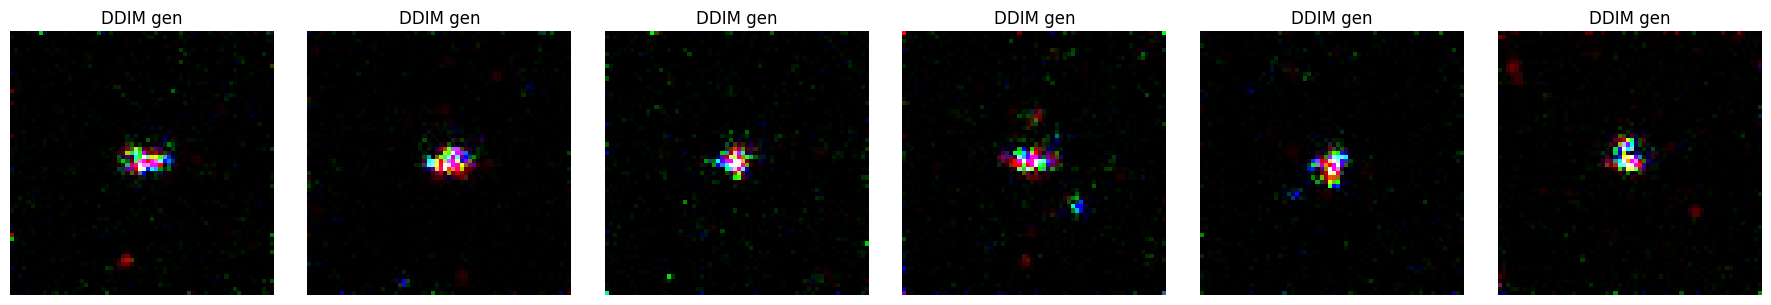

In [24]:
imgs = generar_jets_ddim(modelo_entrenado, scheduler, num_imagenes=6, shape=(3, 64, 64), num_pasos_ddim=50, mostrar=True, max_mostrar=6, contrast=True)

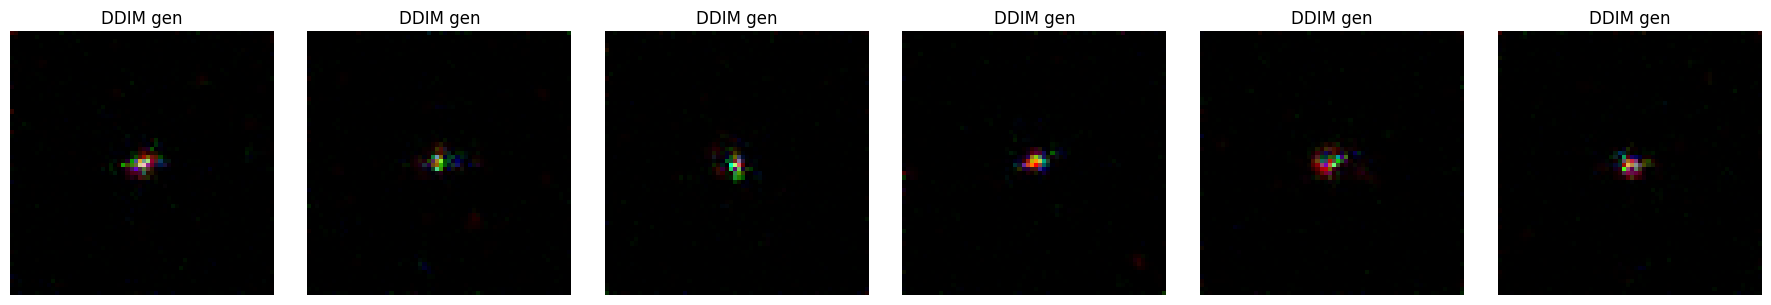

In [25]:
imgs = generar_jets_ddim(modelo_entrenado, scheduler, num_imagenes=6, shape=(3, 64, 64), num_pasos_ddim=50, mostrar=True, max_mostrar=6, contrast=False)

In [33]:
n_eval_gen = 128
jets_gen_eval = generar_jets_ddim(modelo_entrenado, scheduler, num_imagenes=n_eval_gen, shape=(3, 64, 64), num_pasos_ddim=10, mostrar=False, contrast=False)
jets_real_eval = obtener_reales_01(test_loader, n=n_eval_gen, device=device)
metricas_gen = evaluar_generacion_jets(x_gen=jets_gen_eval.to(device), x_real_ref=jets_real_eval, active_thr=0.0001, num_bins=32)
mostrar_metricas(metricas_gen, titulo='Generación desde cero DDIM')


Generación desde cero DDIM


,valor
E_w1,16.688677
active_frac_w1,0.247603
max_intensity_w1,0.076322
participation_ratio_w1,77.282520
energy_real_mean,25.535656
energy_gen_mean,42.224335
active_frac_real_mean,0.047497
active_frac_gen_mean,0.295100
max_real_mean,0.939186
max_gen_mean,0.878975


In [ ]:
@torch.no_grad()
def reconstruccion_iterativa_desde_xt_ddim(model, scheduler, loader, device, t_start=50, n=4, num_pasos_ddim=None, mostrar=True, contrast=True):
    model.eval()
    x0, _ = next(iter(loader))
    x0 = x0[:n].float().to(device)
    n_real = x0.shape[0]
    noise = torch.randn_like(x0)
    t_start_tensor = torch.full((n_real,), t_start, device=device, dtype=torch.long)
    x_t, noise_real = scheduler.add_noise(x0=x0, t=t_start_tensor, noise=noise)
    x = x_t.clone()
    x0_pred_final = None

    if num_pasos_ddim is None or num_pasos_ddim >= t_start + 1:
        timesteps = torch.arange(t_start, -1, -1, device=device, dtype=torch.long)
    else:
        timesteps = torch.linspace(t_start, 0, num_pasos_ddim, device=device).round().long()
        timesteps = torch.unique_consecutive(timesteps)
        if timesteps[-1].item() != 0:
            timesteps = torch.cat([timesteps, torch.tensor([0], device=device, dtype=torch.long)])
    for i in range(len(timesteps)):
        t = timesteps[i]
        if i + 1 < len(timesteps):
            t_prev = timesteps[i + 1]
        else:
            t_prev = torch.tensor(-1, device=device, dtype=torch.long)
        t_batch = torch.full((n_real,), int(t.item()), device=device, dtype=torch.long)
        v_pred = model(x, t_batch)
        x, x0_pred = scheduler.sample_prev_timestep_v(xt=x, v_pred=v_pred, t=t, t_prev=t_prev, clip_x0=True)
        x0_pred_final = x0_pred
    x0_pred_final = torch.clamp(x0_pred_final, -1.0, 1.0)
    mse = torch.mean((x0_pred_final - x0) ** 2).item()
    print(f'MSE reconstrucción DDIM desde t={t_start}: {mse:.6f}')
    x0_vis = torch.clamp((x0 + 1.0) / 2.0, 0.0, 1.0).cpu()
    xt_vis = torch.clamp((x_t + 1.0) / 2.0, 0.0, 1.0).cpu()
    recon_vis = torch.clamp((x0_pred_final + 1.0) / 2.0, 0.0, 1.0).cpu()

    if mostrar:
        fig, axes = plt.subplots(n_real, 3, figsize=(9, 3 * n_real), squeeze=False)
        for i in range(n_real):
            img0 = x0_vis[i][[2, 0, 1]].permute(1, 2, 0).numpy()
            imgt = xt_vis[i][[2, 0, 1]].permute(1, 2, 0).numpy()
            imgr = recon_vis[i][[2, 0, 1]].permute(1, 2, 0).numpy()
            axes[i, 0].imshow(img0, origin='lower')
            axes[i, 0].set_title('Original')
            axes[i, 0].axis('off')
            axes[i, 1].imshow(imgt, origin='lower')
            axes[i, 1].set_title(f'Degradada $x_t$, t={t_start}')
            axes[i, 1].axis('off')
            axes[i, 2].imshow(imgr, origin='lower')
            axes[i, 2].set_title('Reconstrucción DDIM')
            axes[i, 2].axis('off')
        plt.tight_layout()
        plt.show()
        
    return {
        'x0': x0.detach().cpu(),
        'x_t': x_t.detach().cpu(),
        'recon': x0_pred_final.detach().cpu(),
        'x0_01': x0_vis,
        'xt_01': xt_vis,
        'recon_01': recon_vis,
        't_start': t_start,
        'mse_original': mse,
        'timesteps': timesteps.detach().cpu(),
        'n_real': n_real,
    }

MSE reconstrucción DDIM desde t=50: 0.000468


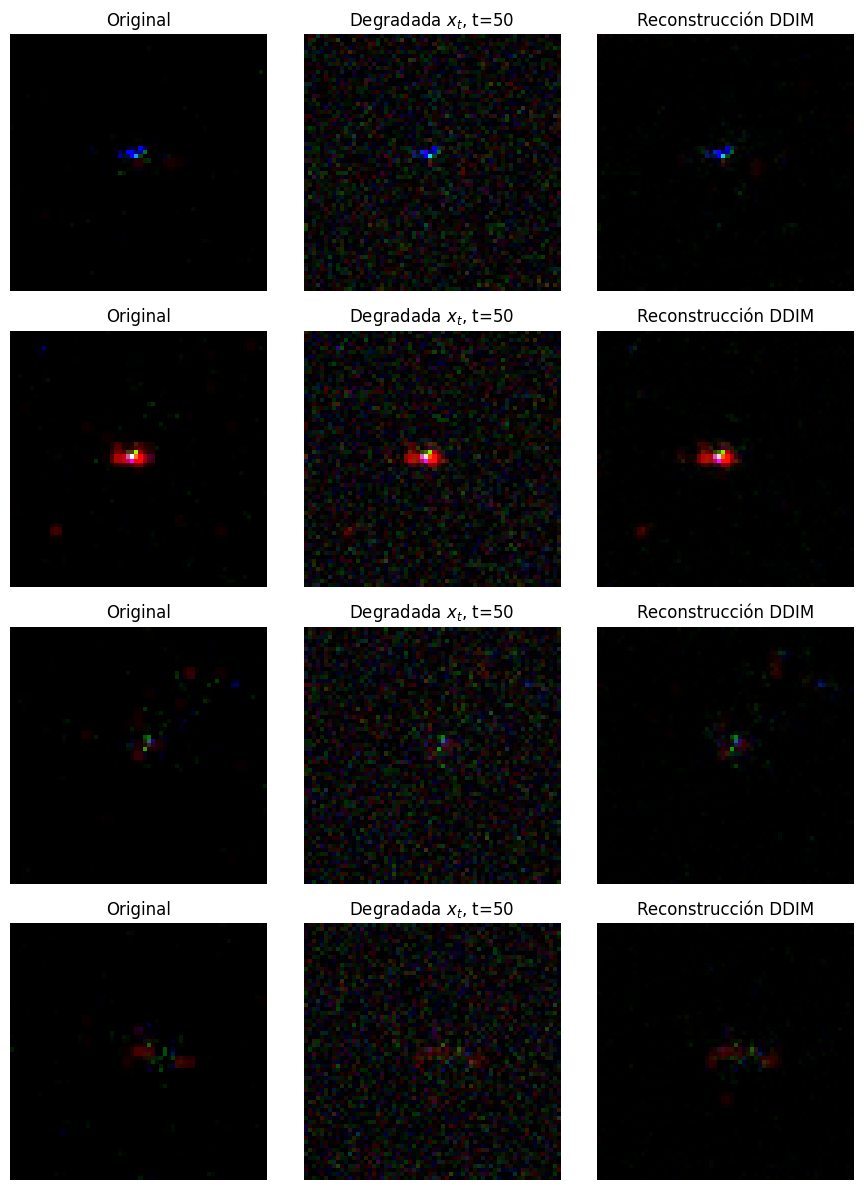

MSE reconstrucción DDIM desde t=100: 0.000791


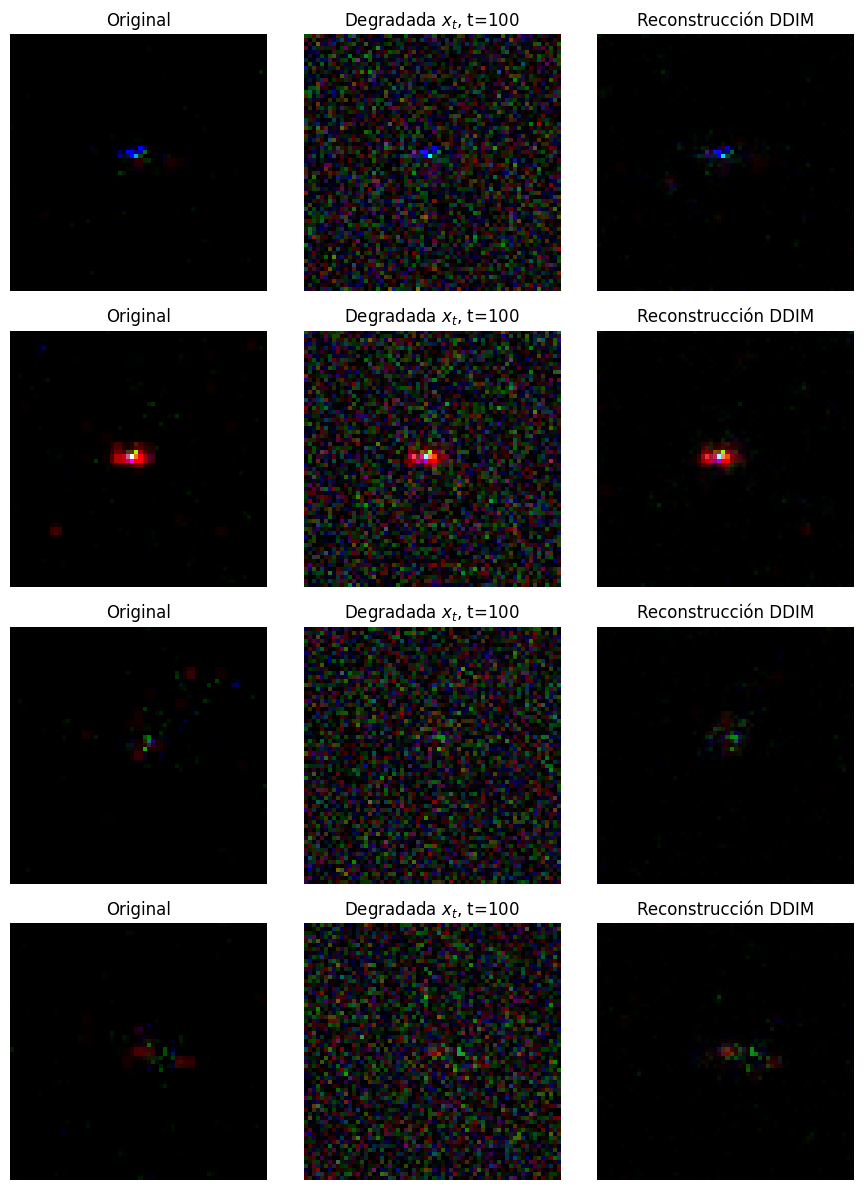

MSE reconstrucción DDIM desde t=200: 0.001897


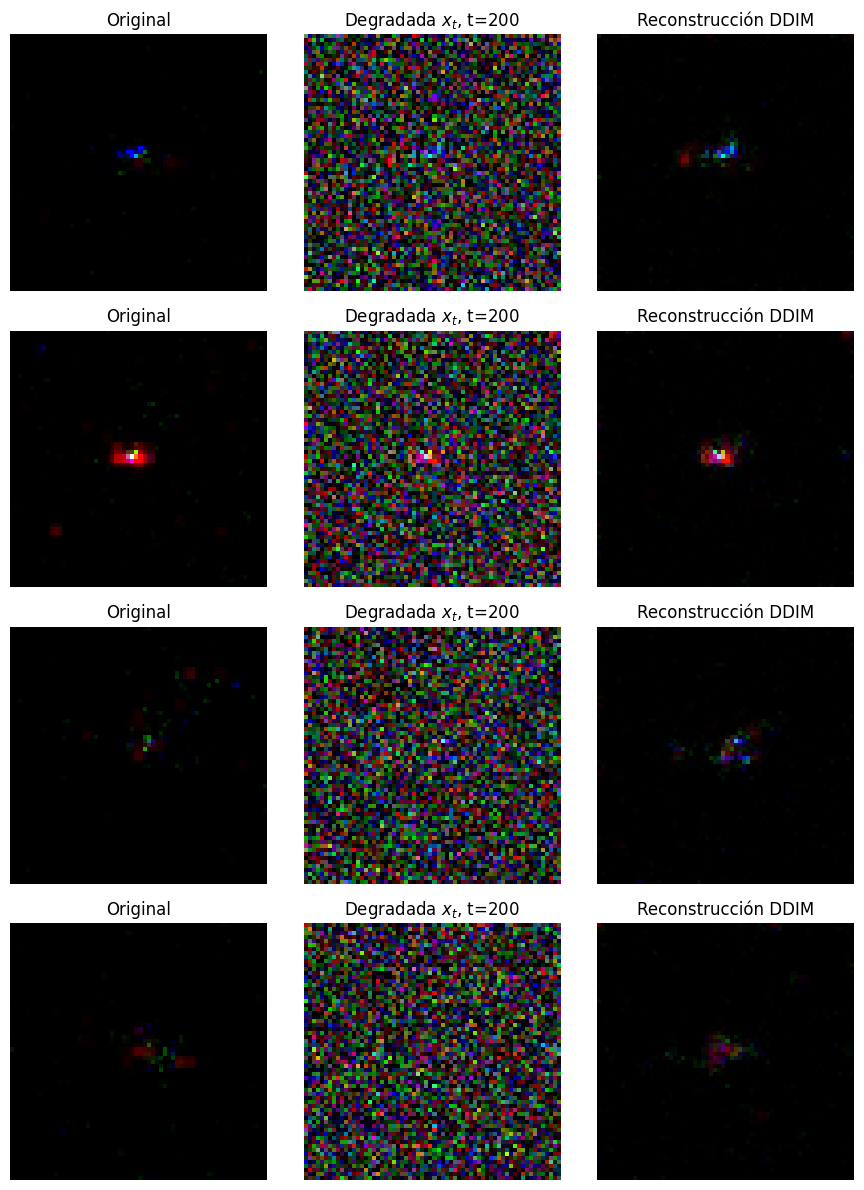

MSE reconstrucción DDIM desde t=500: 0.003382


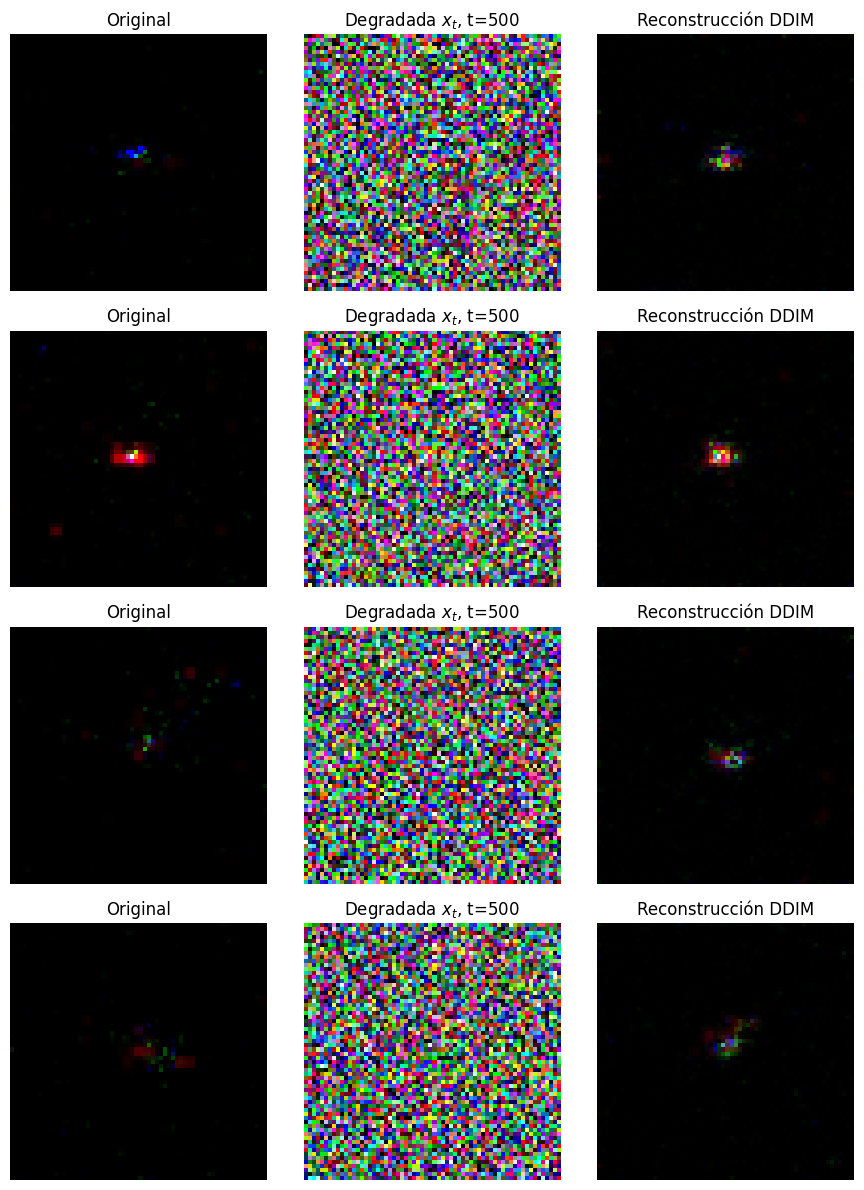

MSE reconstrucción DDIM desde t=999: 0.004398


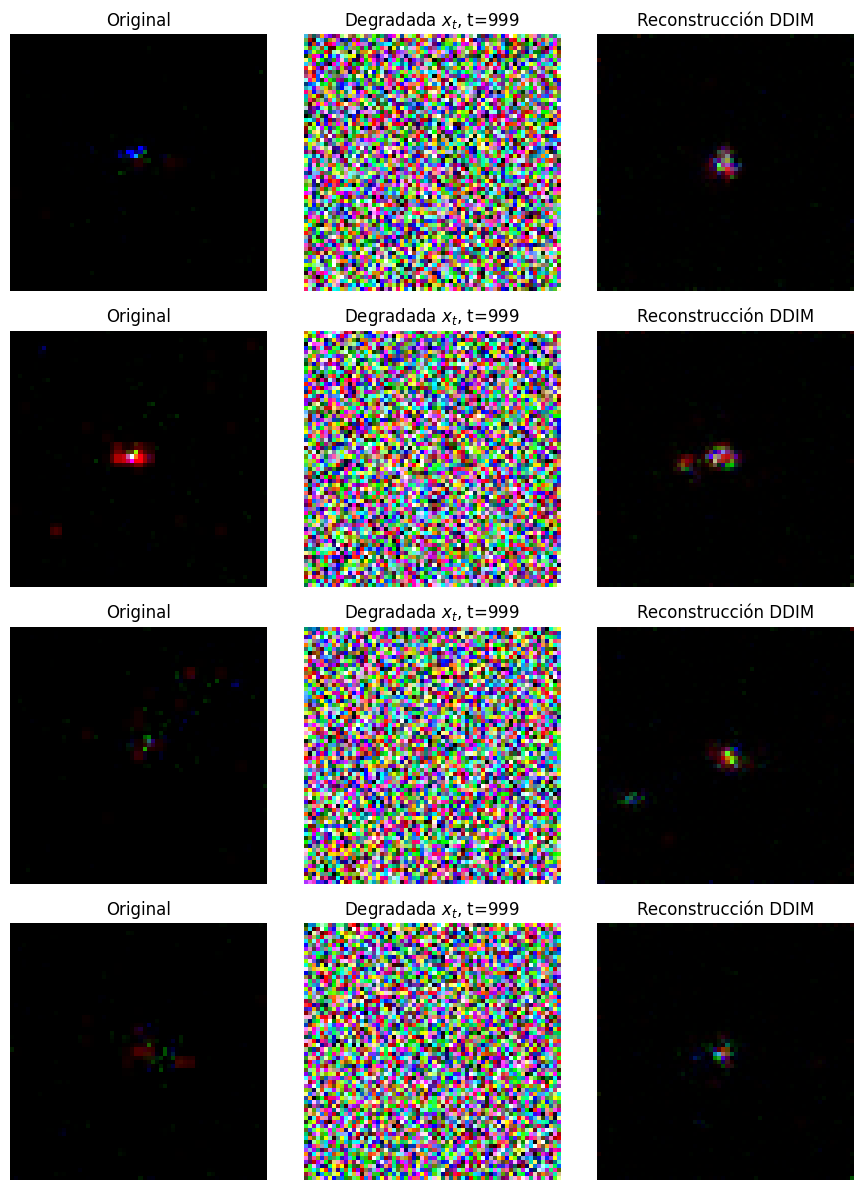

In [35]:
recon_50_raw = reconstruccion_iterativa_desde_xt_ddim(
    modelo_entrenado, scheduler, test_loader, device, t_start=50, n=4, num_pasos_ddim=26, mostrar=True,
    contrast=False,
)
recon_100_raw = reconstruccion_iterativa_desde_xt_ddim(
    modelo_entrenado, scheduler, test_loader, device, t_start=100, n=4, num_pasos_ddim=26, mostrar=True,
    contrast=False,
)
recon_200_raw = reconstruccion_iterativa_desde_xt_ddim(
    modelo_entrenado, scheduler, test_loader, device, t_start=200, n=4, num_pasos_ddim=26, mostrar=True,
    contrast=False,
)
recon_500_raw = reconstruccion_iterativa_desde_xt_ddim(
    modelo_entrenado, scheduler, test_loader, device, t_start=500, n=4, num_pasos_ddim=51, mostrar=True,
    contrast=False,
)
recon_1000_raw = reconstruccion_iterativa_desde_xt_ddim(
    modelo_entrenado, scheduler, test_loader, device, t_start=999, n=4, num_pasos_ddim=51, mostrar=True,
    contrast=False,
)


Visualización de reconstrucción DDIM | t_start = 50
MSE reconstrucción DDIM desde t=50: 0.000403


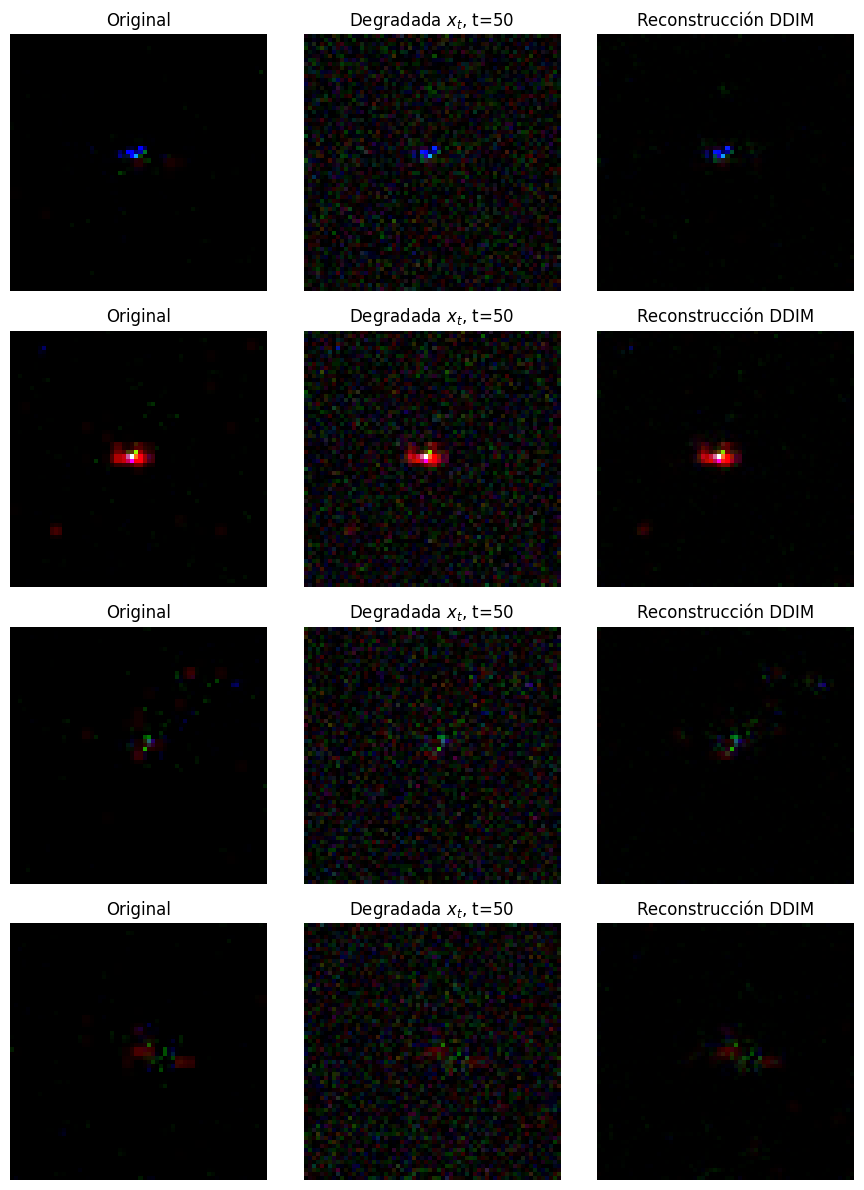


Visualización de reconstrucción DDIM | t_start = 200
MSE reconstrucción DDIM desde t=200: 0.001635


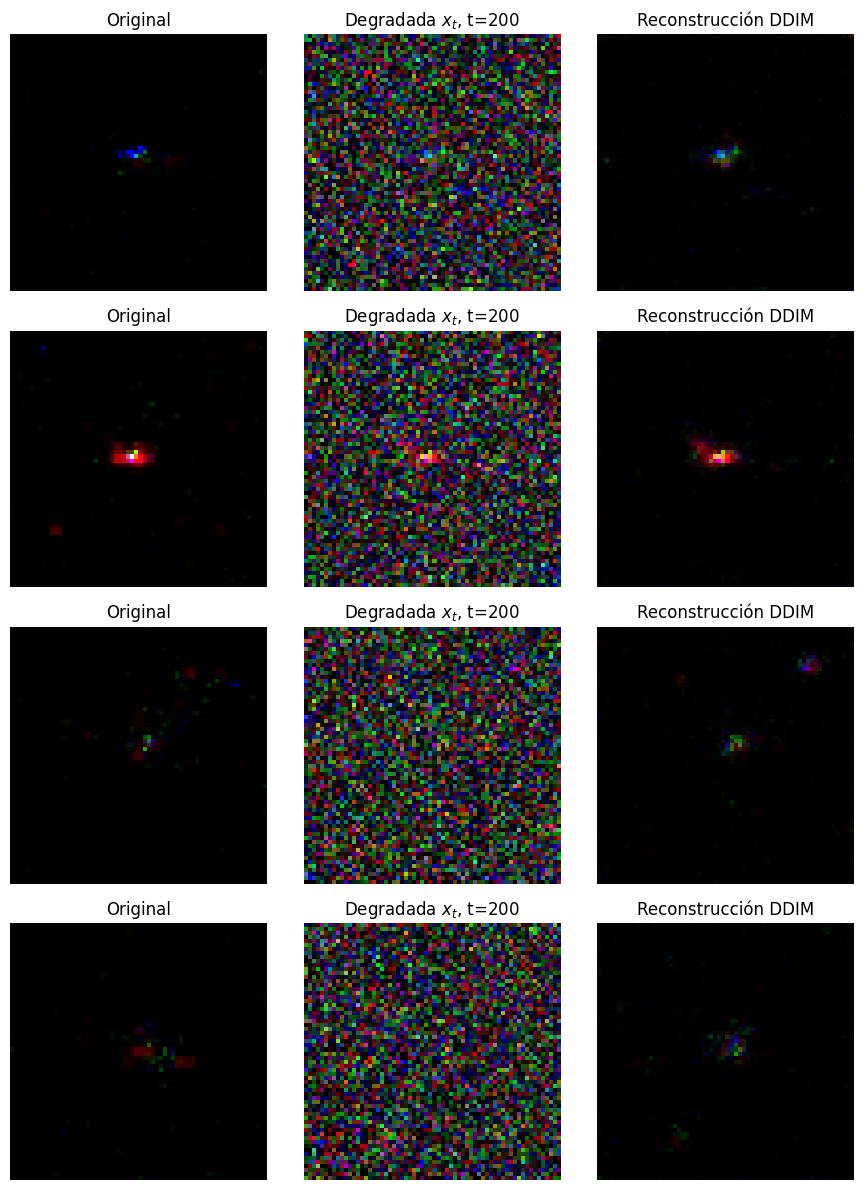


Visualización de reconstrucción DDIM | t_start = 500
MSE reconstrucción DDIM desde t=500: 0.003888


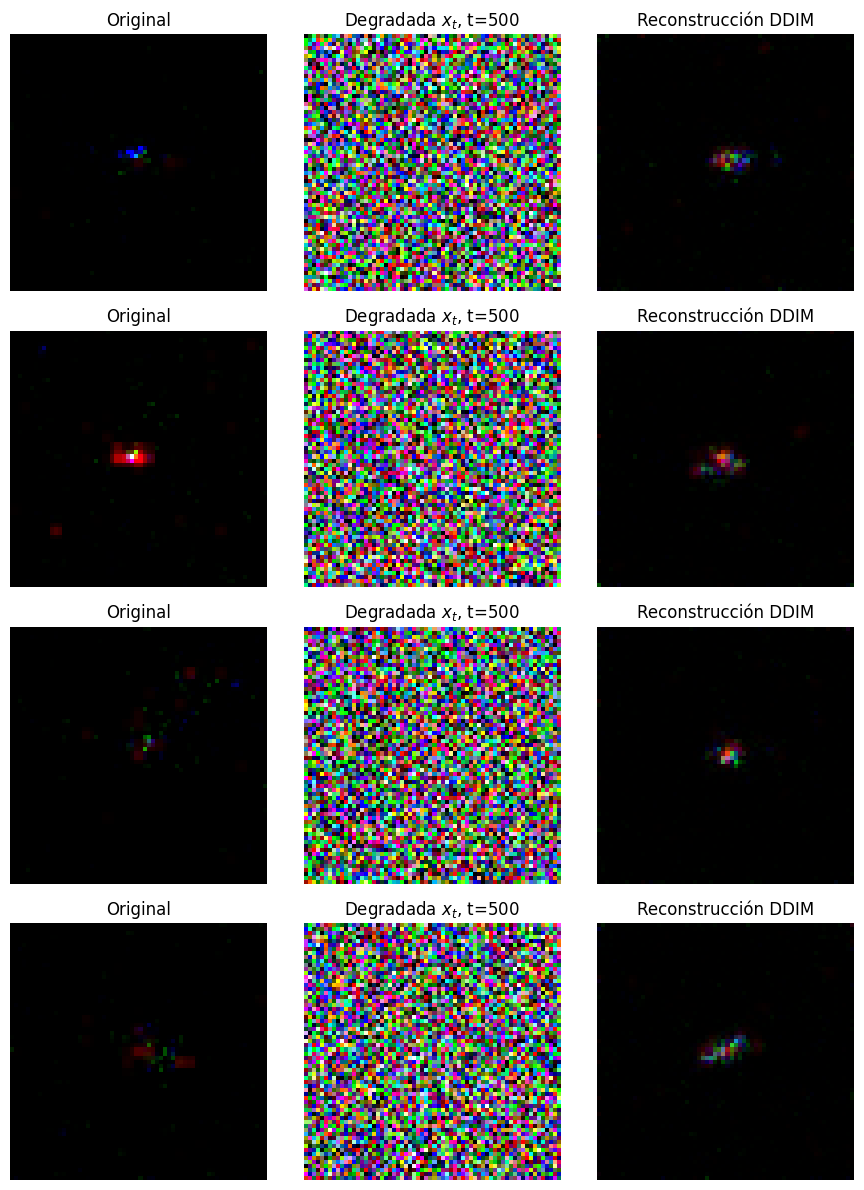


Visualización de reconstrucción DDIM | t_start = 999
MSE reconstrucción DDIM desde t=999: 0.005230


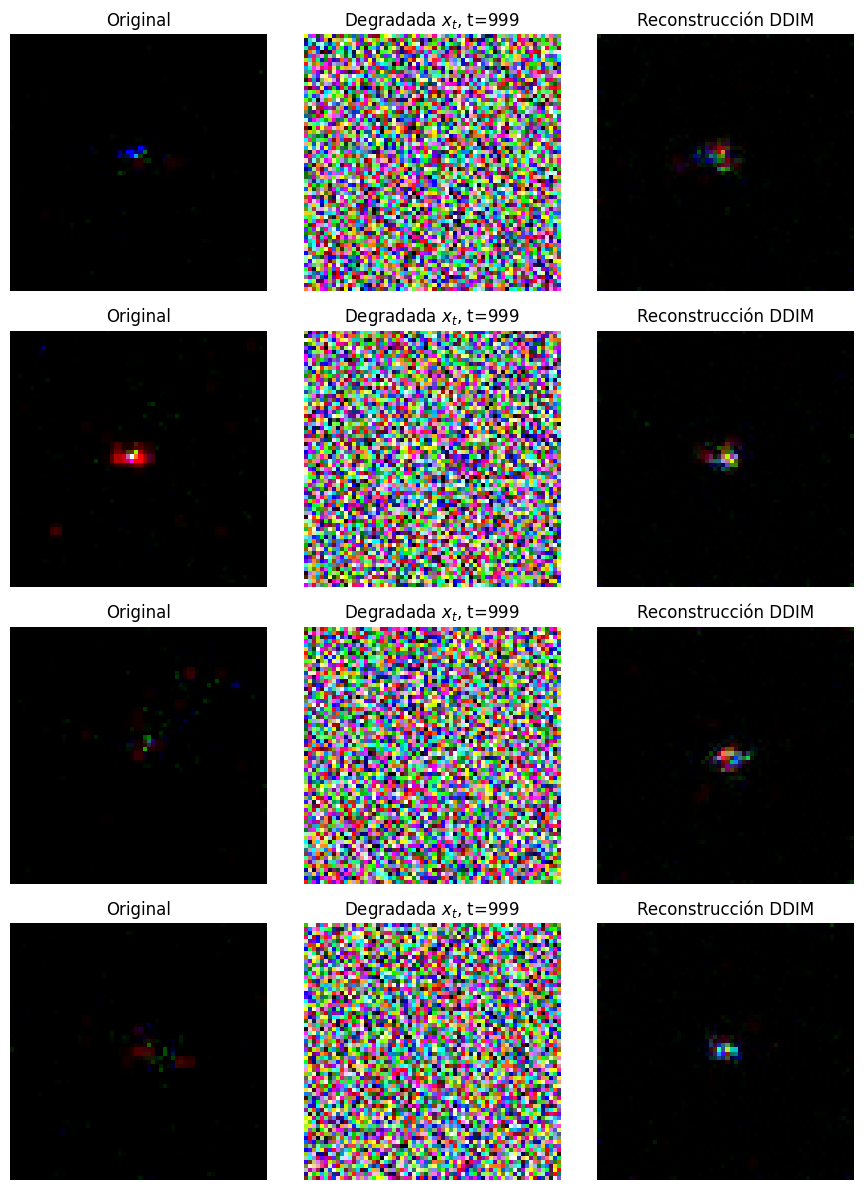

In [36]:
for t_vis, pasos_vis in [(50, 10), (200, 25), (500, 25), (999, 100)]:
    print('\n' + '=' * 70)
    print(f'Visualización de reconstrucción DDIM | t_start = {t_vis}')
    print('=' * 70)
    _ = reconstruccion_iterativa_desde_xt_ddim(
        modelo_entrenado, scheduler, test_loader, device, t_start=t_vis, n=4, num_pasos_ddim=pasos_vis,
        mostrar=True, contrast=False,
    )

In [38]:
@torch.no_grad()
def resumen_intensidades_pixeles(x, nombre='imagen', thresholds=None, eps=1e-12):
    if thresholds is None:
        thresholds = [0.0, 1e-06, 1e-05, 0.0001, 0.0005, 0.001, 0.005, 0.01]
    x = to_01(x).detach().float().cpu()
    pix = x.reshape(-1)
    datos = {}
    datos[f'{nombre}_min'] = pix.min().item()
    datos[f'{nombre}_max'] = pix.max().item()
    datos[f'{nombre}_mean'] = pix.mean().item()
    datos[f'{nombre}_std'] = pix.std().item()
    for q in [0.5, 0.9, 0.95, 0.99, 0.995, 0.999]:
        datos[f'{nombre}_q{q}'] = torch.quantile(pix, q).item()
    datos[f'{nombre}_frac_exact_zero'] = (pix <= eps).float().mean().item()
    for thr in thresholds:
        datos[f'{nombre}_frac_gt_{thr:g}'] = (pix > thr).float().mean().item()
        datos[f'{nombre}_energy_gt_{thr:g}'] = pix[pix > thr].sum().item()
    df = pd.DataFrame.from_dict(datos, orient='index', columns=['valor'])
    display(df)
    return datos

In [39]:
@torch.no_grad()
def graficar_histograma_intensidades(x_real, x_pred, nombre_pred='Generada/Recons', bins=200, eps=1e-12, log_y=True):
    x_real = to_01(x_real).detach().float().cpu().reshape(-1)
    x_pred = to_01(x_pred).detach().float().cpu().reshape(-1)
    plt.figure(figsize=(8, 5))
    plt.hist(x_real.numpy(), bins=bins, alpha=0.5, density=True, label='Real')
    plt.hist(x_pred.numpy(), bins=bins, alpha=0.5, density=True, label=nombre_pred)
    if log_y:
        plt.yscale('log')
    plt.xlabel('Intensidad del píxel en escala [0, 1]')
    plt.ylabel('Densidad')
    plt.title('Histograma de intensidades de píxeles')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

@torch.no_grad()
def graficar_histograma_intensidades_positivas(x_real, x_pred, nombre_pred='Generada/Recons', bins=200, eps=1e-08, log_y=True):
    x_real = to_01(x_real).detach().float().cpu().reshape(-1)
    x_pred = to_01(x_pred).detach().float().cpu().reshape(-1)
    x_real_pos = x_real[x_real > eps]
    x_pred_pos = x_pred[x_pred > eps]
    plt.figure(figsize=(8, 5))
    plt.hist(x_real_pos.numpy(), bins=bins, alpha=0.5, density=True, label='Real > 0')
    plt.hist(x_pred_pos.numpy(), bins=bins, alpha=0.5, density=True, label=f'{nombre_pred} > 0')
    if log_y:
        plt.yscale('log')
    plt.xlabel('Intensidad del píxel en escala [0, 1]')
    plt.ylabel('Densidad')
    plt.title('Histograma de intensidades positivas')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

In [40]:
@torch.no_grad()
def aplicar_corte_pixeles(x, threshold):
    x = to_01(x).detach().clone()
    x[x < threshold] = 0.0
    return x

In [41]:
@torch.no_grad()
def evaluar_cortes_generacion(x_gen, x_real_ref, thresholds=None, num_bins=32):
    if thresholds is None:
        thresholds = [0.0, 1e-06, 1e-05, 0.0001, 0.0005, 0.001, 0.002, 0.005, 0.01, 0.02, 0.05]
    x_gen = to_01(x_gen)
    x_real_ref = to_01(x_real_ref).to(x_gen.device)
    filas = []
    for thr in thresholds:
        x_gen_cut = aplicar_corte_pixeles(x_gen, thr).to(x_gen.device)
        obs_real = jet_observables(x_real_ref, active_thr=thr)
        obs_gen = jet_observables(x_gen_cut, active_thr=thr)
        fila = {
            'threshold': thr,
            'energy_real_mean': obs_real['energy'].mean().item(),
            'energy_gen_mean': obs_gen['energy'].mean().item(),
            'energy_ratio_gen_real': obs_gen['energy'].mean().item() / (obs_real['energy'].mean().item() + 1e-08),
            'active_frac_real_mean': obs_real['active_frac'].mean().item(),
            'active_frac_gen_mean': obs_gen['active_frac'].mean().item(),
            'active_frac_ratio_gen_real': obs_gen['active_frac'].mean().item() / (obs_real['active_frac'].mean().item() + 1e-08),
            'max_real_mean': obs_real['max_intensity'].mean().item(),
            'max_gen_mean': obs_gen['max_intensity'].mean().item(),
            'E_w1': w1_samples(obs_gen['energy'], obs_real['energy']),
            'active_frac_w1': w1_samples(obs_gen['active_frac'], obs_real['active_frac']),
            'max_intensity_w1': w1_samples(obs_gen['max_intensity'], obs_real['max_intensity']),
        }
        filas.append(fila)
    df = pd.DataFrame(filas)
    display(df)
    return df

In [42]:
@torch.no_grad()
def evaluar_reconstruccion_con_fondo(x_rec, x_real, active_thr=0.0001):
    x_rec = to_01(x_rec)
    x_real = to_01(x_real)
    active_real = x_real > active_thr
    background_real = x_real <= active_thr
    metricas = {}
    metricas['mse_total'] = F.mse_loss(x_rec, x_real).item()
    if active_real.sum() > 0:
        metricas['mse_en_pixeles_activos_reales'] = ((x_rec - x_real) ** 2)[active_real].mean().item()
        metricas['energia_real_activa'] = x_real[active_real].sum().item()
        metricas['energia_rec_en_activos_reales'] = x_rec[active_real].sum().item()
    else:
        metricas['mse_en_pixeles_activos_reales'] = np.nan
        metricas['energia_real_activa'] = np.nan
        metricas['energia_rec_en_activos_reales'] = np.nan
    if background_real.sum() > 0:
        metricas['mse_en_fondo_real'] = ((x_rec - x_real) ** 2)[background_real].mean().item()
        metricas['energia_falsa_en_fondo'] = x_rec[background_real].sum().item()
        metricas['intensidad_media_fondo_rec'] = x_rec[background_real].mean().item()
        metricas['frac_fondo_rec_mayor_thr'] = (x_rec[background_real] > active_thr).float().mean().item()
    else:
        metricas['mse_en_fondo_real'] = np.nan
        metricas['energia_falsa_en_fondo'] = np.nan
        metricas['intensidad_media_fondo_rec'] = np.nan
        metricas['frac_fondo_rec_mayor_thr'] = np.nan
    metricas['energia_real_total'] = x_real.sum().item()
    metricas['energia_rec_total'] = x_rec.sum().item()
    metricas['ratio_energia_rec_real'] = metricas['energia_rec_total'] / (metricas['energia_real_total'] + 1e-08)
    metricas['active_frac_real'] = active_real.float().mean().item()
    metricas['active_frac_rec'] = (x_rec > active_thr).float().mean().item()
    df = pd.DataFrame.from_dict(metricas, orient='index', columns=['valor'])
    display(df)
    return metricas

,valor
real_min,0.000000
real_max,1.000000
real_mean,0.002078
real_std,0.025677
real_q0.5,0.000000
real_q0.9,0.000000
real_q0.95,0.000000
real_q0.99,0.042533
real_q0.995,0.085529
real_q0.999,0.363097


,valor
generada_min,0.000000
generada_max,1.000000
generada_mean,0.003436
generada_std,0.029474
generada_q0.5,0.000000
generada_q0.9,0.003162
generada_q0.95,0.005296
generada_q0.99,0.070964
generada_q0.995,0.166464
generada_q0.999,0.484353


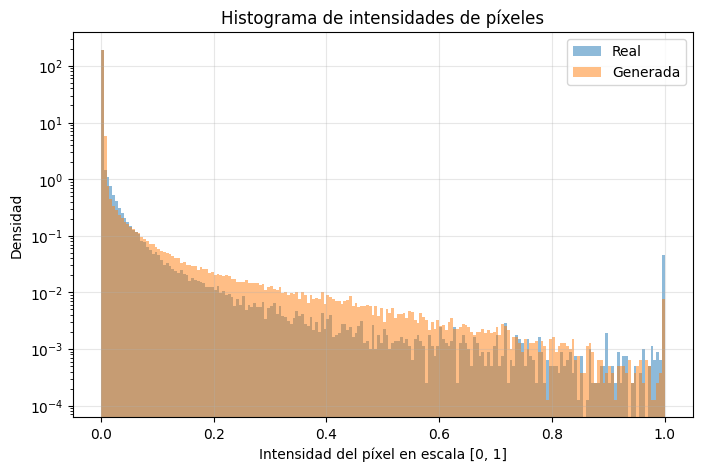

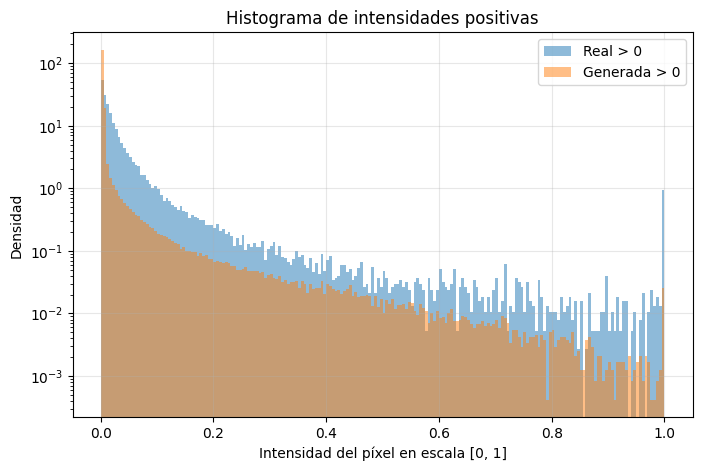

,threshold,energy_real_mean,energy_gen_mean,energy_ratio_gen_real,active_frac_real_mean,active_frac_gen_mean,active_frac_ratio_gen_real,max_real_mean,max_gen_mean,E_w1,active_frac_w1,max_intensity_w1
0,0.000000,25.535656,42.224335,1.653544,0.047846,0.304452,6.363191,0.939186,0.878974,16.688678,0.256606,0.076322
1,0.000001,25.535656,42.224331,1.653544,0.047846,0.304355,6.361158,0.939186,0.878974,16.688677,0.256509,0.076322
2,0.000010,25.535656,42.224274,1.653542,0.047825,0.303485,6.345677,0.939186,0.878974,16.688618,0.255660,0.076322
3,0.000100,25.535656,42.218594,1.653319,0.047497,0.295100,6.213048,0.939186,0.878974,16.682940,0.247603,0.076322
4,0.000500,25.535656,42.087757,1.648196,0.045886,0.259315,5.651332,0.939186,0.878974,16.552099,0.213430,0.076322
5,0.001000,25.535656,41.716846,1.633670,0.044214,0.218829,4.949297,0.939186,0.878974,16.181193,0.174615,0.076322
6,0.002000,25.535656,40.524227,1.586966,0.041354,0.152966,3.698900,0.939186,0.878974,14.988575,0.111612,0.076322
7,0.005000,25.535656,36.652100,1.435330,0.034801,0.054296,1.560187,0.939186,0.878974,11.167422,0.019495,0.076322
8,0.010000,25.535656,34.338875,1.344742,0.027404,0.025486,0.930005,0.939186,0.878974,8.926290,0.004259,0.076322
9,0.020000,25.535656,33.312515,1.304549,0.018141,0.019559,1.078117,0.939186,0.878974,7.958074,0.002888,0.076322


In [43]:
resumen_intensidades_pixeles(jets_real_eval, nombre='real')
resumen_intensidades_pixeles(jets_gen_eval, nombre='generada')
graficar_histograma_intensidades(jets_real_eval, jets_gen_eval, nombre_pred='Generada', bins=200, log_y=True)
graficar_histograma_intensidades_positivas(jets_real_eval, jets_gen_eval, nombre_pred='Generada', bins=200, log_y=True)
df_cortes_gen = evaluar_cortes_generacion(
    jets_gen_eval, jets_real_eval,
    thresholds=[0.0, 1e-06, 1e-05, 0.0001, 0.0005, 0.001, 0.002, 0.005, 0.01, 0.02, 0.05], num_bins=32,
)

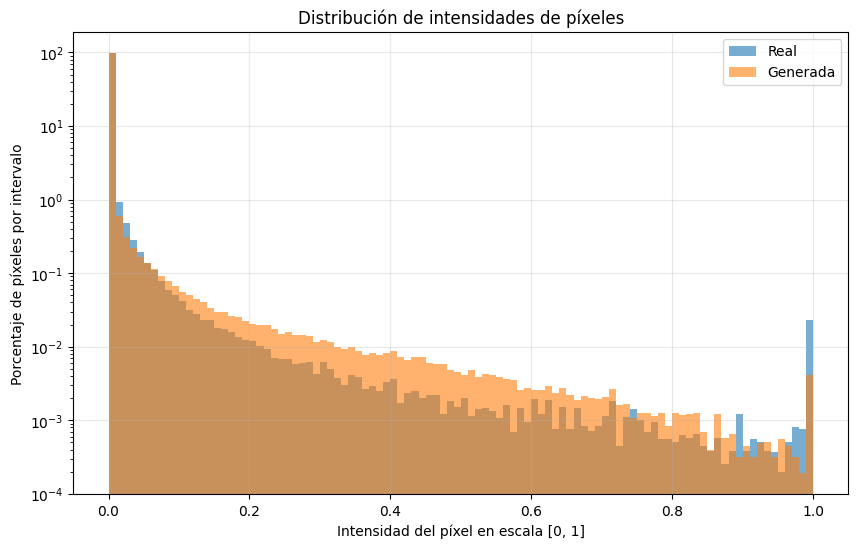

In [44]:
import numpy as np
import matplotlib.pyplot as plt
real = jets_real_eval.detach().cpu().numpy().ravel()
generada = jets_gen_eval.detach().cpu().numpy().ravel()
bins = np.linspace(0, 1, 101)
weights_real = np.ones_like(real) * 100.0 / len(real)
weights_gen = np.ones_like(generada) * 100.0 / len(generada)
plt.figure(figsize=(10, 6))
plt.hist(real, bins=bins, weights=weights_real, alpha=0.6, label='Real')
plt.hist(generada, bins=bins, weights=weights_gen, alpha=0.6, label='Generada')
plt.yscale('log')
plt.xlabel('Intensidad del píxel en escala [0, 1]')
plt.ylabel('Porcentaje de píxeles por intervalo')
plt.title('Distribución de intensidades de píxeles')
plt.legend()
plt.grid(alpha=0.3)
plt.show()